<a href="https://colab.research.google.com/github/poliane-poliane/Notas-de-aula-cientista-de-dados/blob/main/Bloco_1_10_Python_para_an%C3%A1lise_de_dados_%7C_M%C3%B3dulo_11_%7C_Projeto_Final_%7C_Anota%C3%A7%C3%A3o_EM_ANDAMENTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final: Análise de dados de crédito


1.   Título;
2.   Breve descrição do problema;
3.   Código de importação de bibliotecas (o ideal é importar todas no início);
4.   Código do download/carregamento/geração de dados (é o import/upload do dataframe a ser usado);
5.   Etapa de exploração (checar dtypes, describe, schema, etc.);
6.   Etapa de transformação e limpeza (dados com tipos errados, valores duplicados, junção de bases de dados, etc.);
7.   Etapa de análise (com visualizações);
8.   Resumo dos *insights* gerados.




#1.   Introdução


Considere que a base de dados que vamos analisar tem a seguinte estrutura:

| Coluna  | Descrição |
| ------- | --------- |
| id      | Número da conta |
| default | Indica se o cliente é adimplente (0) ou inadimplente (1) |
| idade   | --- |
| sexo    | --- |
| depedentes | --- |
| escolaridade | --- |
| estado_civil | --- |
| salario_anual | Faixa do salario mensal multiplicado por 12 |
| tipo_cartao | Categoria do cartao: blue, silver, gold e platinium |
| meses_de_relacionamento | Quantidade de meses desde a abertura da conta |
| qtd_produtos | Quantidade de produtos contratados |
| iteracoes_12m | Quantidade de iteracoes com o cliente no último ano |
| meses_inatico_12m | Quantidade de meses que o cliente ficou inativo no último ano |
| limite_credito | Valor do limite do cartão de crédito |
| valor_transacoes_12m | Soma total do valor das transações no cartão de crédito no último ano |
| qtd_transacoes_12m | Quantidade total de transações no cartão de crédito no último ano |

Considerando esses dados, podemos conduzir uma série de análises. Algumas possíveis são:



1.   ***Perfil dos Clientes por Tipo de Cartão***

    * Entender como clientes com diferentes tipos de cartão (blue, silver, gold, platinum) se distribuem em termos de salário, crédito e comportamento.
        *   Clientes platinum têm, em média, salários maiores e mais produtos contratados?
        *   Qual tipo de cartão tem maior número médio de transações no ano?
        *   Existe diferença no número médio de meses de relacionamento entre os tipos?


2.   ***Análise de Engajamento com a Empresa***

    *   Investigar o comportamento de engajamento (interações, uso do cartão, tempo de relacionamento).
        *   Correlação entre `meses_de_relacionamento` e `iteracoes_12m`.
        *   Clientes com mais meses inativos (`meses_inativo_12m`) também fazem menos transações?


3.   ***Análise do Uso do Limite de Crédito***

    *   Avaliar o quanto os clientes usam do limite disponível.
        *   Criar uma nova variável: `uso_percentual_limite = valor_transacoes_12m / limite_credito`.
        *  Analisar a distribuição desse percentual por faixa salarial, tipo de cartão ou escolaridade.
        *  Existe uso excessivo do limite em algum grupo específico?


4.   ***Perfis Sociodemográficos e Comportamento***

    *   Entender como variáveis como `idade`, `sexo`, `estado_civil`, `escolaridade` influenciam no comportamento de uso.
        *   Qual o ticket médio por sexo ou escolaridade?
        *   Há diferença no número médio de produtos contratados entre estados civis?
        *   Quais grupos usam mais o cartão, mas têm menos interações?


5.   ***Churn e Fatores de Risco de Saída***

    *   Analisar quem são os clientes que estão deixando de interagir.
        *   Filtrar clientes com `meses_inativo_12m > 6`.
        *   Comparar esses clientes com os demais em termos de salário, tipo de cartão, transações.
        *   Tentar prever saída com base no perfil. Nesse caso, levantar quais possíveis dados seriam necessários para calcular o custo da perda em comparação com a projeção da entrada de novos clientes (a perda compensa? É válido fazer ações para reter? Quais?).

6.   ***Análise de Ciclo de Vida do Cliente***

    *   *Investigar como o relacionamento evolui com o tempo.
        *   Como variam as transações conforme os `meses_de_relacionamento` aumentam?
        *   Existe uma curva de engajamento (ex.: crescimento no início, queda depois)?










#2.   Breve descrição do problema



3.   ***Análise do Uso do Limite de Crédito***

    *   **Objetivo**: avaliar o quanto os clientes usam do limite disponível.
        *   Criar uma nova variável: `uso_percentual_limite = valor_transacoes_12m / limite_credito`.
        *  Analisar a distribuição desse percentual por faixa salarial, tipo de cartão ou escolaridade.
        *  Existe uso excessivo do limite em algum grupo específico?



Para isso, irei conduzir os seguintes passos:



1.   **Schema e Transformação**: Avaliar a qualidade dos dados, a consistência e se os dados estão nos formatos corretos (float, int, etc.). Corrigir, caso necessário. Aqui utilizamos o método `describe()` para avaliar a consistência de dados.
2.   **Limpeza**: caso haja dados faltantes, remover.
3.   **Novas variáveis**: Avaliar a necessidade de criar novas colunas para o estudo a ser conduzido. No nosso caso, isso será necessário.
4.   **Pré-análise**: usar o método `describe()` para fazer uma análise preliminar de dados categóricos e numéricos.
5.   **Análise**: Iniciar a análise de dados.


#3.   Código de importação de bibliotecas

In [ ]:
import pandas as pd

#4.   Código do download/carregamento/geração de dados


In [ ]:
df = pd.read_csv('ebac_arquivo_projeto_final_modulo_python.csv', na_values = 'na')

#5.   Exploração de dados

## Estrutura

In [ ]:
df.head(n=7)

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,"4.010,69","1.088,07",24
6,810347208,0,51,M,4,NaN,casado,$120K +,gold,46,6,3,1,"34.516,72","1.330,87",31


Vejamos quantas linhas e colunas tem a base:

In [ ]:
df.shape

(10127, 16)

Vamos checar 2 coisas:



1.   Schema: checar se o tipo dos dados está de acordo com o tipo esperado pelos dados da coluna (exemplo: coluna com `id` jamais poderá ser tipo `float`, pois trata-se de um número de identificação, podendo ser string ou int).
2.   Dados faltantes: checar se o número de elementos das colunas está em consistência com o número de linhas da tabela de dados.




Checando se os tipos de cada dado está condizente com o tipo de dado que a coluna deve armazenar.

## Schema (Qualidade dos dados)

Para analisar a **qualidade dos dados** (*schema*) precisamos avaliar 2 pontos principais:



1.   ***Avaliar consistência dos dados***: Para isso, podemos usar o método `describe()`, para avaliarmos se o número de dados está consistente com o número de linhas e colunas do data frame.
2.   ***Avaliar tipo dos dados***: Para isso, checamos se os dados estão com os tipos corretos (se o que é string está com o tipo `string` ou `object`; se o que é para ser número real está como `float`, e assim por diante).







### Schema (Qualidade dos dados): Consistência de dados categóricos e numéricos

Inicialmente vamos avaliar a consistência dos dados. Aqui utilizamos o método `describe()` para avaliar a consistência de dados categóricos e numéricos em comparação com os dados gerais do data frame.

O método `describe()` é um método do pandas que permite fazer resumos de dados e exibir de forma visual.

Vamos ver abaixo como usá-lo aplicando para variáveis tipo `string` e tipo `number`.

Para isso, vamos usar o `select_dtypes` para que esse resumo dos dados seja feito com relação às colunas que possuem o tipo de dado selecionado. O `transpose`vai ser usado para melhor visualização dos dados.


> 💡 **Resumo do método `describe()`**
>
> O método `describe()` nos ajuda a avaliar a consistência dos dados, no sentido de detalhar o tipo de dados em cada coluna e de nos permitir avaliar se os dados estão completos ou faltantes, além de permitir fazer uma visualização analítica prévia dos dados: saber quais são os maiores tipos, etc.
>
> O `describe()` exibe colunas com atributos diferentes para variáveis categóricas e para variáveis numéricas.
>
> 🔸**Para variáveis categóricas**, o `describe()` exibe:
>
> 1. **count** – número de valores não nulos. Faz a contagem dos dados para uma dada variável. Pode ajudar a verificar que a quantidade de dados está de acordo com o número de linhas do dataframe. Se houver menos dados que o número de linha, pode sugerir dados faltantes ou de outra natureza.  
> 2. **unique** – número de valores distintos. Indica quantos tipos diferentes te. Se o tipo de dado for booleano, indica só 2; se o tipo de dado for, por exemplo, letras A, B, C, D, E, irá indicar 5; se o tipo de dado for float, vai contar o número de valores únicos.  
> 3. **top** – valor mais frequente. Indica qual, dentre os dados disponíveis para aquela coluna, é o dado que mais se repete. Se entre A, B, C, D, E, o dado que mais se repete entre os dados de uma dada coluna é a letra A, então ele será o valor que vai aparecer em top para aquela coluna.  
> 4. **freq** – frequência do valor mais frequente. Indica a frequência com que o dado em top se repete. Então se A é o dado que mais se repete em uma coluna, o dado de freq indica quantas vezes a letra A se repete.  
>
> 🔹**Para variáveis numéricas**, o `describe()` exibe:
>
> 1. **count** – número de valores não nulos  
> 2. **mean** – média  
> 3. **std** – desvio padrão (standard deviation)  
> 4. **min** e **max** – valores mínimo e máximo  
> 5. **25%**, **50%**, **75%** – quartis (1º, 2º e 3º quartis)  




Vejamos agora como isso se aplica às variáveis/atributos categóricos e aos numéricos.



*   **Atributos categóricos**

São aqueles cujo conjunto de valores é finito. Exemplo: a variável sexo só pode ter 2 valores: F ou M.

Vamos ver o `describe`aplicado a dados tipo `object`, com o `transpose` (para facilitar a visualização).



In [ ]:
df.select_dtypes('object').describe().transpose() #experimente remover o .transpose() para ver a vantagem em usá-lo

,count,unique,top,freq
sexo,10127,2,F,5358
escolaridade,8608,5,mestrado,3128
estado_civil,9378,3,casado,4687
salario_anual,9015,5,menos que $40K,3561
tipo_cartao,10127,4,blue,9436
limite_credito,10127,9272,"1.438,21",11
valor_transacoes_12m,10127,10035,"3.851,51",3


Note que, quando usamos o comando `df.shape()`, vimos que há 10127 linhas e 16 colunas. Entretanto, no resultado do comando acima, podemos ver que as colunas  `escolaridade`, `estado_civil` e `salario_anual`têm menos de 10127 dados, sugerindo que nas linhas dessas colunas pode não haver dados, indicando, portanto, inconsistência dos dados. Nesse momento, não vamos fazer nada a respeito disso, porque isso é feito na etapa de Limpeza (Transformação) e, por enquanto, estamos na parte do Schema. Por ora, sabemos que os dados categóricos está inconsistentes.

Agora vejamos para dados numéricos.

*   **Atributos numéricos**

São aqueles cujo conjunto de valores podem assumir infinitos valores. Exemplo: as variáveis tipo inteiro e float.

Vamos escrever o mesmo para as variáveis numéricas:

In [ ]:
df.select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,10127.0,7.391776e+08,3.690378e+07,708082083.0,713036770.5,717926358.0,773143533.0,828343083.0
default,10127.0,1.606596e-01,3.672348e-01,0.0,0.0,0.0,0.0,1.0
idade,10127.0,4.632596e+01,8.016814e+00,26.0,41.0,46.0,52.0,73.0
dependentes,10127.0,2.346203e+00,1.298908e+00,0.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,10127.0,3.592841e+01,7.986416e+00,13.0,31.0,36.0,40.0,56.0
qtd_produtos,10127.0,3.812580e+00,1.554408e+00,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,10127.0,2.455317e+00,1.106225e+00,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,10127.0,2.341167e+00,1.010622e+00,0.0,2.0,2.0,3.0,6.0
qtd_transacoes_12m,10127.0,6.485869e+01,2.347257e+01,10.0,45.0,67.0,81.0,139.0


Veja que o `id` está configurado como inteiro, mas não faz sentido, já que é só um numero de identificação, poderíamos muito bem tratá-lo como string, mas sua configuração de dados veio como `int`; por isso, no `describe()`, seus valores são imensos. Para ignorar a coluna de ids, podemos usar o método `drop()`.

>💡 **Resumo do método `drop()`**
>
> 🔸 O `drop()` é usado para remover linhas ou colunas de um dataframe. Sua anatomia geral é:
>
> ```
># dataframe.drop(labels, axis = 0, inplace = False)
>```
>🔹🔹**labels**: Nome da coluna(s) ou índice(s) que você quer remover.
>
>🔹🔹**axis**: Define se está removendo uma linha (`axis = 0`) ou uma coluna (`axis = 1`)
>
>🔹🔹**inplace**: Se `True`, altera o dataframe origina. Se `False` (padrão), retorna uma cópia sem os elementos removidos.

Para remover a coluna `id` da visualização, portanto, usamos o comando:

In [ ]:
df.drop('id', axis = 1).select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.0,0.0,0.0,0.0,1.0
idade,10127.0,46.325960,8.016814,26.0,41.0,46.0,52.0,73.0
dependentes,10127.0,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,10127.0,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0
qtd_produtos,10127.0,3.812580,1.554408,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,10127.0,2.455317,1.106225,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,10127.0,2.341167,1.010622,0.0,2.0,2.0,3.0,6.0
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0


Como o count de todas as colunas selecionadas é igual ao número de linhas do dataframe (como vimos do `df.shape`), então aparentemente não temos problemas de consistência com os dados dessas colunas.

Como constatamos que só há inconsistência dos dados nos atributos categóricos, podemos desde já avaliar em que porporção esses dados faltantes se manifestam com relação à base de dados original.

#### Verificando dados faltantes: Método `isna()`e `any()`

Podemos verificar quais colunas possuem dados faltantes usando o método `isna()` para localizar os dados faltantes e o método `any()`para filtrar as colunas de interesse:

In [ ]:
df.isna().any()

,0
id,False
default,False
idade,False
sexo,False
dependentes,False
escolaridade,True
estado_civil,True
salario_anual,True
tipo_cartao,False
meses_de_relacionamento,False


As colunas`escolaridade`, `estado_civil`e `salario_anual` acusaram `True`, indicando que elas possuem dados faltantes.

Mas **como descobrir a quantidade de daods faltantes**?

Vamos definir a seguinte função que irá imprimir qual é essa quantidade de dados faltantes nas 3 colunas que acusaram `True` e a porcentagem.

**Note que essa função retorna `None`porque ela retorna um print, então não é para retornar nada mesmo.**

In [ ]:
df.columns.to_list() # teste remover o .to_list() para entender o objetivo de uaá-lo

['id',
 'default',
 'idade',
 'sexo',
 'dependentes',
 'escolaridade',
 'estado_civil',
 'salario_anual',
 'tipo_cartao',
 'meses_de_relacionamento',
 'qtd_produtos',
 'iteracoes_12m',
 'meses_inativo_12m',
 'limite_credito',
 'valor_transacoes_12m',
 'qtd_transacoes_12m']

Agora, vamos fazer uma espécie de loop columa por coluna na função abaixo para achamaos os valores faltantes em termos percentuais:

In [ ]:
def stats_dados_faltantes(df: pd.DataFrame) -> None:

  stats_dados_faltantes = []
  for col in df.columns:
    if df[col].isna().any():
      qtd, _ = df[df[col].isna()].shape
      total, _ = df.shape
      dict_dados_faltantes = {col: {'quantidade': qtd, 'porcentagem': round(100 * qtd / total, 2)}}
      stats_dados_faltantes.append(dict_dados_faltantes)

  for stat in stats_dados_faltantes:
    print(stat)

Chamando a função para operar sobre o nosso df:

In [ ]:
stats_dados_faltantes(df = df)

{'escolaridade': {'quantidade': 1519, 'porcentagem': 15.0}}
{'estado_civil': {'quantidade': 749, 'porcentagem': 7.4}}
{'salario_anual': {'quantidade': 1112, 'porcentagem': 10.98}}


Ou seja:



*   Em **escolaridade** temos 1519 dados faltantes, ou seja, 15% da nossa base na coluna de escolaridade
*   Em **estado_civil**, vimos que há 749 dados faltantes; temos 7.4% de dados faltantes na base dessa coluna.
*   Em **salario_anual**, vimos que há 1112 dados faltantes; temos 10.98% de dados faltantes na base dessa coluna.


Como nossa base está desbalanceada (inadimplentes e adimplentes), vamos ver como essa falta de dados se dá para cada tipo de cliente:

In [ ]:
stats_dados_faltantes(df = df[df['default'] == 0])

{'escolaridade': {'quantidade': 1263, 'porcentagem': 14.86}}
{'estado_civil': {'quantidade': 620, 'porcentagem': 7.29}}
{'salario_anual': {'quantidade': 925, 'porcentagem': 10.88}}


In [ ]:
stats_dados_faltantes(df = df[df['default'] == 1])

{'escolaridade': {'quantidade': 256, 'porcentagem': 15.73}}
{'estado_civil': {'quantidade': 129, 'porcentagem': 7.93}}
{'salario_anual': {'quantidade': 187, 'porcentagem': 11.49}}


🚨🚨**Por que queremos verificar isso?**

Note que o que vimos nas 2 linhas de código acima foi que o percentual de dados faltantes tanto para adimplentes quanto para inadimplentes é bem próximo, ou seja, é bem equilibrado: para a coluna de escolaridade, 14.86% dos dados faltantes são de de inadimplentes (0) e 15.73% são de adimplentes (1), ou seja, são bem próximos; para estado_civil e salario_anual a dfierença também é pequena.

Quando essa diferença é pequena, podemos tratar esses dados faltantes **por meio da remoção dessas linhas com dados faltantes**. Sim, vamos perder: cerca de 15% dos dados da base da coluna escolaridade; cerca de 7% dos dados da base da coluna estado_civil e cerca de 11% dos dados da base da coluna salario_anual.

**Mas isso é delicado!!!!!!!!!!!!!!!!!!!!!!**

Caso a maior parte dos dados de um ou outro possa vir a ser perdida no processo de remoção, isso seria bem ruim e o tratamento desses dados faltantes fosse pela via da remoção das linhas de dados faltantes seria enviesado.

Com isso, finalizamos a etapa de ***Avaliar consistência dos dados*** da etapa de Schema; agora vamos ***avaliar o tipo de dados***.

### Schema (Qualidade dos dados): Tipos de dados

Vejamos abaixo o tipo de dado contido em cada variável do data frame.

In [ ]:
df.dtypes

,0
id,int64
default,int64
idade,int64
sexo,object
dependentes,int64
escolaridade,object
estado_civil,object
salario_anual,object
tipo_cartao,object
meses_de_relacionamento,int64


Note que os dados das colunas `limite_credito`e `valor_transacoes_12m` são tipo `object`, de modo que vamos precisar realizar a alteração desses dados para o tipo `float`. Só a título de curiosidade, podemos ver o tipo de dado de colunas específicas usando o código abaixo:




In [ ]:
# Para vermos o dtypes só das colunas selecionadas, basta usar o df.dtypes só que agora passando a lista com as colunas desejadas
df[ ['limite_credito', 'valor_transacoes_12m'] ].dtypes

,0
limite_credito,object
valor_transacoes_12m,object


 Isso aconteceu porque os dados estão escritos no formato brasileiro de escrever números: `NN.NNN,NN`, como pode ser visto quando imprimimos uma parte das primeiras linhas do dataframe acima e como pode ser visto de forma mais enxuta usando o comando abaixo:

In [ ]:
df[ ['limite_credito', 'valor_transacoes_12m'] ].head(n=5)

,limite_credito,valor_transacoes_12m
0,"12.691,51","1.144,90"
1,"8.256,96","1.291,45"
2,"3.418,56","1.887,72"
3,"3.313,03","1.171,56"
4,"4.716,22","816,08"


Feito isso, seguimos com a parte de **transformação** dos dados para os tipos necessários, mantendo a consistência necessária dos dados.

#6.   Transformação e limpeza dos dados

A etapa de **transformação** também tem 2 partes:



1.   **Tranformação de dados**: Nessa etapa definimos funções que vão ser usadas para mudar o tipo de dados do dataframe, caso alguns estejam com o tipo errado.
2.   **Limpeza**: Essa é uma etapa mais delicada e que visa realizar ajustes para manter a consistência dos dados no que diz respeito à variáveis que possuem dados faltantes. Nessa etapa, avaliamos o impacto da remoção de linhas e/ou colunas com alguns dados faltantes e, caso a proporção de dados se mantenha (com relação à proporção no dataframe original), podemos seguir com a remoção dessas linhas/colunas.


### Transformação dos dados

Veja que, de fato, os dados acima estão com o formato brasileiro de números. O que vamos fazer é remover os pontos e trocar as vírgulas por ponto.

Para isso, vamos criar uma função `lambda`para limpar os dados.

Mas antes, vamos **testar** como ela se aplica aos dados apenas da coluna limite_credito através do método funcional `map` e `lambda`.

Só relembrando que:




*   Anatomia da função `lambda`


```
 variavel = lambda parametros: expressao
```


*   Anatomia da função `map`


```
 variavel = map(funcao , colecao)
```

Então vamos criar uma lista com os dados dessa coluna e aplicar a função `map`. Se virmos que o teste deu certo, aí, sim, vamos aplicar ao nosso dataframe.

Primeiro, vamos criar a lista com alguns valores da coluna `limite_credito`; podemos considerar os 5 primeiros valores. Com isso, a gente vai criar uma mini base de dados, chamada `valores_originais` sobre a qual vamos testar a função de transformação `lambda` criada e que será aplicada à mini base de dados usando a função `map`.

In [ ]:
valores_originais = df['limite_credito'].head(n=5)
valores_originais = list(valores_originais) # preciso inserir esse linha; caso contrário, ele imprime como coluna
print(valores_originais) # esse print não é necessário

['12.691,51', '8.256,96', '3.418,56', '3.313,03', '4.716,22']


O `print` foi só para vermos que dessa forma é possível selecionar só alguns valores da coluna, em vez de todos os valores. Caso quiséssemos todos, bastava remover o `head`.

Agora vamos escrever a função `lambda`.

Nesse caso (em que vamos substituir o método brasileiro de escrita de números pelo americano), queremos:

*   remover os pontos, que é *equivalente a* **substituir** ponto por nada/vazio; e
*   **substituir** vírgula por ponto.


Para isso, vamos usar a função `replace()` **DUAS VEZES**.

In [ ]:
funcao_teste = lambda valor: float(valor.replace(".", "").replace(",", "."))

Essa é a função. Note que a função é apenas `funcao_teste = lambda valor: valor.replace(".", "").replace(",", ".")`. Mas adicionamos o `float`para que o valor, após as substituições, seja convertido para float.

Agora vamos aplicar a função `lambda` na mini base de dados criada (`valores_originais`) usando a função `map`:

In [ ]:
# Chamando a função através da função map

valores_limpos = map(funcao_teste, valores_originais)
valores_limpos = list(valores_limpos)
print(valores_limpos)

[12691.51, 8256.96, 3418.56, 3313.03, 4716.22]


Portanto vimos que **FUNCIONOU!!!!**

Vamos compilar tudo em uma célula de código e renomeando a `funcao_teste` por `funcao`, como iremos chamar na hora de aplicar aos nossos dados do data frame original:

In [ ]:
# 1º: listar a coleção sobre a qual vamos aplicar a função de transformação/substituição dos dados
valores_originais = list(df['limite_credito'].head(n=5))

# 2º: definindo a função de substituição
funcao = lambda valor: float( valor.replace(".","").replace(",",".") )

# 3º: aplicando a função de substituição à coleção a ser transformada e convertendo em lista
valores_limpos = list(map(funcao, valores_originais))

print(valores_limpos)

[12691.51, 8256.96, 3418.56, 3313.03, 4716.22]


Agora que vimos que funcionou, vamos aplicar isso aos dados das duas colunas com problema, usando a **função** `apply()`.

In [ ]:
# Tranformando os dados da coluna limite_credito
df['limite_credito'] = df['limite_credito'].apply(funcao)

# Tranformando os dados da coluna valor_transacoes_12m
df['valor_transacoes_12m'] = df['valor_transacoes_12m'].apply(funcao)

Vamos ver o schema novamente para ver que agora são tipo float:

In [ ]:
df.dtypes

,0
id,int64
default,int64
idade,int64
sexo,object
dependentes,int64
escolaridade,object
estado_civil,object
salario_anual,object
tipo_cartao,object
meses_de_relacionamento,int64


### Limpeza dos dados: Remoção de dados faltantes

Já ao ler o conjunto de fados, indicamos ao Python uma forma de interpretar dados faltantes por meio de



```
na_values = 'na'
```

de modo que, toda vez que ele encontra um dado faltante ele substitui por `NaN`.

Sendo assim, como o pandas, portanto, está ciente de um dado faltante, a remoção das linhas problemáticas é trivial.

Para isso, usamos o método `dropna`, para ignorar/pular as linhas com dados faltantes.

Nesse caso, podemos usar `df.dropna(inplace=True)` ou `df_atualizado = df.dropna()`. Vamos usar esse último porque, enquanto o primeiro altera o próprio dataframe **diretamente**, sem criar uma cópia (ou seja, os valores ausentes  são removidos do próprio df, e ele é modificado em memória), o segundo atribui o dataframe original a uma variável (vamos chamar aqui de `df_ajustado`), removendo as linhas com NaN; aqui o processo ocorre via atribuição, e não via alteração direta.


In [ ]:
df_ajustado = df.dropna() ## # cria um novo dataframe sem NaNs e salva na variável df; df agora é o novo dataframe sem NaNs

Vamos analisar a estrutura dos dados novamente agora que removemos os dados ausentes:

In [ ]:
df_ajustado.shape

(7081, 16)

Na seção ***Verificando dados faltantes: Método `isna()`e `any()`***, vimos que:

*   Em **escolaridade** temos 1519 dados faltantes, ou seja, 15% da nossa base na coluna de escolaridade
*   Em **estado_civil**, vimos que há 749 dados faltantes; temos 7.4% de dados faltantes na base dessa coluna.
*   Em **salario_anual**, vimos que há 1112 dados faltantes; temos 10.98% de dados faltantes na base dessa coluna.

Como essas foram as colunas que nos trouxeram até essa etapa (já que foi pela constatação de que elas estavam inconsistentes por terem dados faltantes), vamos avaliar a proporção percentual de cada tipo de diferente de entrada (valores únicos) em cada uma dessas colunas agora que fizemos a remoção de dados.

In [ ]:
# quero dividir a qtde total de linhas com ensino medio pela qtde total de linhas do data frame; depois fazer o mesmo para mestrado, sem educação formal, etc
# isso vai exibir uma taxa desses tipos de escolaridades antes da limpeza de dados
# depois fazer a mesma divisão, porém com a qtde total de linhas após a limpeza dos dados; a ideia é comparar essas taxas

nome_coluna = ['escolaridade', 'estado_civil', 'salario_anual', 'default']
qtd_total_antes = df.shape[0]
qtd_total_depois = df_ajustado.shape[0]

for nome in nome_coluna:
    # Como default não tem um título decente, vou colocar essa etapa
    nome_exibicao = 'Situação de pagamento' if nome == 'default' else nome.capitalize()

    print(f'Proporção ANTES e DEPOIS da limpeza de dados para a coluna {nome_exibicao}\n')

    tipos_unicos = df[nome].unique()

    for tipo in tipos_unicos:
        # Esse if pé para adicionar Adimplente e Inadimplente no print de exibição do nome no print final
        if nome == 'default':
            if tipo == 0:
                tipo_exibicao = 'Adimplentes'
            elif tipo == 1:
                tipo_exibicao = 'Inadimplentes'
            else:
                tipo_exibicao = 'Não informado'
        else:
            tipo_exibicao = tipo

        # Contagem considerando NaNs
        if pd.isna(tipo): #inseri essa parti porque quanto tipo==nan, a comparação não funciona, porque NaN não é igual a nada, nem a ele mesmo, de modo que a expressão retorna False sempre, em todas as linhas
            # Abaixo:
            # df['escolaridade'].isna() faz uma consulta booleana onde cada valor é True se for NaN; False caso contrário
            #.sum() conta quantos True existem
            qtd_antes = df[nome].isna().sum()
            qtd_depois = df_ajustado[nome].isna().sum()
        else:
            qtd_antes = df[df[nome] == tipo].shape[0]
            qtd_depois = df_ajustado[df_ajustado[nome] == tipo].shape[0]

        # Proporções antes e depois
        perc_antes = round((qtd_antes / qtd_total_antes) * 100, 2)
        perc_depois = round((qtd_depois / qtd_total_depois) * 100, 2)
        diferenca = round(perc_depois - perc_antes, 2)

        print(f'Proporção de {tipo_exibicao}: ANTES: {perc_antes}% | DEPOIS: {perc_depois}% | Diferença: {diferenca}%')

    print()

Proporção ANTES e DEPOIS da limpeza de dados para a coluna Escolaridade

Proporção de ensino medio: ANTES: 19.88% | DEPOIS: 23.34% | Diferença: 3.46%
Proporção de mestrado: ANTES: 30.89% | DEPOIS: 36.59% | Diferença: 5.7%
Proporção de sem educacao formal: ANTES: 14.68% | DEPOIS: 17.0% | Diferença: 2.32%
Proporção de nan: ANTES: 15.0% | DEPOIS: 0.0% | Diferença: -15.0%
Proporção de graduacao: ANTES: 10.0% | DEPOIS: 11.92% | Diferença: 1.92%
Proporção de doutorado: ANTES: 9.55% | DEPOIS: 11.14% | Diferença: 1.59%

Proporção ANTES e DEPOIS da limpeza de dados para a coluna Estado_civil

Proporção de casado: ANTES: 46.28% | DEPOIS: 50.33% | Diferença: 4.05%
Proporção de solteiro: ANTES: 38.94% | DEPOIS: 41.63% | Diferença: 2.69%
Proporção de nan: ANTES: 7.4% | DEPOIS: 0.0% | Diferença: -7.4%
Proporção de divorciado: ANTES: 7.39% | DEPOIS: 8.04% | Diferença: 0.65%

Proporção ANTES e DEPOIS da limpeza de dados para a coluna Salario_anual

Proporção de $60K - $80K: ANTES: 13.84% | DEPOIS: 15.

Aproveitei e adicinei essa checagem da proporção com relação à coluna de Adimplentes e Inadimplentes (como foi feito em aula).

Notamos que, após a remoção dos dados faltantes, temos uma diferença de, no máximo, 5,7% a mais em dados (caso de dados de mestrado); isso ignorando dados de NaN.



## Adição de uma nova coluna

Vimos na seção que a análise que iremos conduzir irá analisar o uso do limite de crédito. Para isso, vamos precisar adicionar uma nova coluna no nosso dataframe ajustado: `uso_percentual_limite = valor_transacoes_12m / limite_credito`. Nosso objetivo será analisar a distribuição desse percentual por faixa salarial, tipo de cartão ou escolaridade e se existe uso excessivo do limite em algum grupo específico.

Para fazer isso, irei definir um dataframe chamado `df_ajustado_final` sobre o qual farei a adição da nova coluna. Para não perder o df original, vou fazer uma cópia do `df_ajustado` e, em seguida, definir a nova coluna de `uso_percentual_limite`:

In [ ]:
df_ajustado_final = df_ajustado.copy()
df_ajustado_final['uso_percentual_limite'] = df_ajustado_final['valor_transacoes_12m'] / df_ajustado_final['limite_credito']

df_ajustado_final.head(n=5)

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,uso_percentual_limite
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,1144.90,42,0.090210
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,1291.45,33,0.156407
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,1887.72,20,0.552197
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,816.08,28,0.173037
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,4010.69,1088.07,24,0.271292


Para retornar a coluna com o valor percentual, fazemos o seguinte:

In [ ]:
df_ajustado_final['uso_percentual_limite'] = (df_ajustado_final['uso_percentual_limite'] * 100).round(2)
df_ajustado_final.head(n=5)

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,uso_percentual_limite
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,12691.51,1144.90,42,9.02
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,8256.96,1291.45,33,15.64
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,3418.56,1887.72,20,55.22
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,4716.22,816.08,28,17.30
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,4010.69,1088.07,24,27.13


Para entendermos o significado dessa métrica, vamos considerar os dados da primeira linha exibida na tabela logo acima: nela, o usuário tem uso_percentual_limite = 9.02, indicando que o usuário usou 9.02% do limite do cartão nas transações que fez nos últimos 12 meses.


Conferindo que uma nova coluna foi adicionada (agora o retorno deve ser 17 em colunas, em vez de 16):

In [ ]:
df_ajustado_final.shape

(7081, 17)

Antes de prosseguirmos, algumas observações:



*   **Dados faltantes**: Como realizamos a adição da coluna fazendo operações com dados do dataframe já ajustado, não é para haver dados faltantes. A título de curiosidades, vamos verificar isso usando o `df.isna().any()` e aplicar o describe (apenas para avaliar a consistência dos dados).
*   **Tipo de dados**: Vamos usar o `dtypes`para avaliar se o tipo de dado da nova coluna é float.


In [ ]:
# CHECAGEM DE DADOS FALTANTES [existência de NaN]
df_ajustado_final.isna().any()

,0
id,False
default,False
idade,False
sexo,False
dependentes,False
escolaridade,False
estado_civil,False
salario_anual,False
tipo_cartao,False
meses_de_relacionamento,False


In [ ]:
# CHECAGEM DE DADOS FALTANTES [consistência de dados]
df_ajustado_final.select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,7081.0,7.390919e+08,3.685244e+07,7.080821e+08,7.130105e+08,7.178438e+08,7.732370e+08,8.282989e+08
default,7081.0,1.571812e-01,3.639972e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
idade,7081.0,4.634769e+01,8.041225e+00,2.600000e+01,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
dependentes,7081.0,2.337805e+00,1.291649e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
meses_de_relacionamento,7081.0,3.598136e+01,8.002609e+00,1.300000e+01,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
qtd_produtos,7081.0,3.819376e+00,1.544444e+00,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
iteracoes_12m,7081.0,2.454456e+00,1.104917e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
meses_inativo_12m,7081.0,2.342607e+00,9.951035e-01,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
limite_credito,7081.0,8.493260e+03,9.126082e+03,1.438000e+03,2.498350e+03,4.287220e+03,1.072940e+04,3.451699e+04
valor_transacoes_12m,7081.0,4.394801e+03,3.468458e+03,5.101600e+02,2.089630e+03,3.831090e+03,4.740510e+03,1.799549e+04


In [ ]:
# TIPOS DE DADOS
df_ajustado_final.dtypes

,0
id,int64
default,int64
idade,int64
sexo,object
dependentes,int64
escolaridade,object
estado_civil,object
salario_anual,object
tipo_cartao,object
meses_de_relacionamento,int64


De agora em diante, vamos seguir com o `df_ajustado_final` para fazer a visualização e análise dos dados.

#7.   Análise e Visualização dos dados

Os dados já estão prontos!

Agora vamos criar diversas visualizações para **correlacionar  VARIÁVEIS EXPLICATIVAS com a VARIÁVEL RESPOSTA** para buscar entender o quanto os clientes usam do limite disponível. Vamos:


*   Analisar a distribuição desse percentual por faixa salarial, tipo de cartão, escolaridade, etc., e;
*    Avaliar se existe uso excessivo do limite em algum grupo específico.

A linha de código logo abaixo é só para avaliar a consistência dos dados finais obtidos após tratamento para variáveis categóricas e numéricas, respectivamente.


In [ ]:
df_ajustado_final.drop('id', axis = 1).select_dtypes('object').describe().transpose()

,count,unique,top,freq
sexo,7081,2,M,3706
escolaridade,7081,5,mestrado,2591
estado_civil,7081,3,casado,3564
salario_anual,7081,5,menos que $40K,2792
tipo_cartao,7081,4,blue,6598


No resultado acima vemos que:



*   A variável *sexo* possui dois valores únicos (F e M), sendo que M é o valor que mais aparece com uma frequência/ocorrência de 3706 dentre os 7081 registros de dados para essa variável;

e da mesma forma se faz a leitura das demais variáveis categórias da tabela acima.

In [ ]:
df_ajustado_final.drop('id', axis = 1).select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,7081.0,0.157181,0.363997,0.00,0.00,0.00,0.00,1.00
idade,7081.0,46.347691,8.041225,26.00,41.00,46.00,52.00,73.00
dependentes,7081.0,2.337805,1.291649,0.00,1.00,2.00,3.00,5.00
meses_de_relacionamento,7081.0,35.981359,8.002609,13.00,31.00,36.00,40.00,56.00
qtd_produtos,7081.0,3.819376,1.544444,1.00,3.00,4.00,5.00,6.00
iteracoes_12m,7081.0,2.454456,1.104917,0.00,2.00,2.00,3.00,6.00
meses_inativo_12m,7081.0,2.342607,0.995104,0.00,2.00,2.00,3.00,6.00
limite_credito,7081.0,8493.259524,9126.082105,1438.00,2498.35,4287.22,10729.40,34516.99
valor_transacoes_12m,7081.0,4394.800669,3468.457771,510.16,2089.63,3831.09,4740.51,17995.49
qtd_transacoes_12m,7081.0,64.503319,23.809330,10.00,44.00,67.00,80.00,134.00


Na tabela logo acima, vemos:

*   A variável *uso_percentual_limite* possui:

 🔸🔸 **média** de 106.22, indicando que, em média, o usuário usou 106.22% do limite do cartão nas transações que fez nos últimos 12 meses. Um uso de mais que 100% indica que muitos ultrapassaram o limite do cartão.

 🔸🔸 **std** (ou *desvio padrão*) de 95.65, o que significa que a maior parte dos clientes está, aproximadamente, dentro do intervalo 106.22%-95.65% e 106.22%+95.65%. Ou seja, a maior parte dos usuários usa entre 10.57% e 201.87% do limite do cartão (lembrando que valores acima de 100% significam que a pessoa está devendo mais do que o limite disponível). Em termos práticos, um desvio padrão alto como esse mostra que não há um padrão de uso homogêneo entre os clientes, pois o uso do cartão está distribuído de maneira muito desigual. Esse cenário pode ocorrer, por exemplo, quando há grupos distintos de usuários: um grupo que raramente chega perto do limite e outro que frequentemente ultrapassa. Essa dispersão elevada também ajuda a explicar porque a média está acima de 100%, já que valores muito altos de uso (outliers) puxam tanto a média para cima quanto aumentam o desvio padrão.

 🔸🔸 **min** de 1.81, indicando que o(s) usuário(s) que menos usou o limite do cartão de crédito usou apenas 1.81% do limite do seu cartão.

🔸🔸**Quartis (25%, 50%, 75%)** são as medidas de percentil, que dividem os dados ordenados em quatro partes iguais.

 🔸🔸➡️➡️ **25% (1º quartil, ou Q1)**: este ponto indica que 25% dos usuários usaram até 30.43% do limite do cartão. Em outras palavras, 25% dos usuários usam *abaixo* deste valor (30,43%).

 🔸🔸➡️➡️ **50% (Mediana, ou Q2)**: este ponto é o valor que está exatamente no meio dos dados. 50% dos usuários estão abaixo dele, e 50% estão acima. Sendo o Q2 (mediana) igual a 74.23%, isso indica que 50% dos usuários usaram até 74.23% do limite do cartão de crédito. A mediana é menos influenciada por valores extremos (máximo e mínimo) do que a média. Inclusive, comparando a mediana (q2) com a média, veja que, enquanto a leitura da média indicava que, em média, os usuários haviam ultrapassado o limite do cartão (usando, em média, 106.22% do limite), a mediana traz um pouco mais de precisão, indicando que metado dos usuários usaram até 74.23% (que é menos que 106.22%).

 🔸🔸➡️➡️ **75% (3º quartil, ou Q3)**: este ponto indica que 75% dos usuários usou um limite de cartão *abaixo* deste valor de 158.34%, ou seja,, indicando que 75% dos usuários usou até 158.34% do limite do cartão de crédito.

 🔸🔸 **max** de 507.95, indicando que o(s) usuário(s) que mais usuou, usou 507.95% do limite do cartão (mais que 5 vezes o limite do cartão de crédito).




e da mesma forma se faz a leitura das demais variáveis categórias da tabela acima.



Só aproveitando para explicar um pouco sobre o conceito de Desvio padrão (ou Standard Deviation, std).



>💡 **Mais um pouco sobre Desvio Padrão (std)**
>
> 🔸 O desvio padrão é a medida de dispersão ou variabilidade dos dados. Ele mede o quanto os valores estão espalhados (variam) em relação à média.
>
>🔹🔹 **Desvio padrão pequeno**: a maioria dos valores está próxima da média, ou seja, são consistentes.
>
>🔹🔹 **Desvio padrão grande**:  os valores estão muito espalhados, com diferenças grandes entre si e/ou com relação à média.
>
>A média sozinha não mostra a variação, mas o desvio padrão revela quão homogêneos ou heterogêneos são os dados.



Começamos então importando os pacotes de visualização e analisando os dados de uso do limite por idade, sexo, dependentes, escolaridade, estado_civil, salario_anual, tipo_cartao, meses_de_relacionamento, iteracoes_12m, meses_inativo_12m, limite_credito, valor_transacoes_12m, qtd_transacoes_12m.

In [ ]:
import matplotlib.pyplot as plt # vai ajudar numa coisa ou outra em termos de funcionalidade
import seaborn as sns # é construído em cima do matplotlib; vamos conseguir ver os gráficos

# vamos usar o set_style do seaborn para definirmos um estilo padrão para todos os nossos gráficos
# Mas no seaborn tem vários outros estilos; basta procurar a documentação do set_style
sns.set_style('whitegrid')

O primeiro gráfico que vamos ver é um histograma. Nele vamos a frequência de uma variável: nesse caso, vamos ver com que frequência os valores percentuais de uso do cartão se repetem. No caso da primeira coluna, por exemplo, vemos que mais de 1000 usuários fizeram uso de até uns 20% do limite do cartão. E assim por diante.

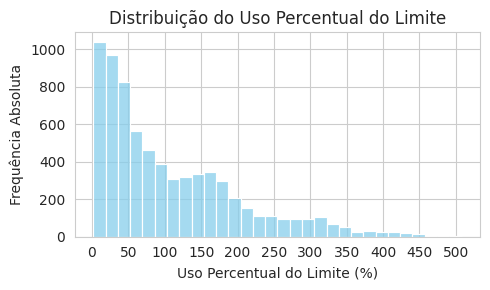

In [ ]:
coluna = 'uso_percentual_limite'
titulo = 'Distribuição do Uso Percentual do Limite'

figura, eixo = plt.subplots(figsize=(5, 3))

# Histograma
sns.histplot(x=coluna, data=df_ajustado_final, stat='count', bins=30, ax=eixo, color='skyblue')

# Título e rótulos
eixo.set(title=titulo, xlabel='Uso Percentual do Limite (%)', ylabel='Frequência Absoluta')

# Altera o espaçamento do eixo horizontal de 50 em 50
eixo.set_xticks(range(0, int(df_ajustado_final[coluna].max())+1, 50))
# explicando:
# df_ajustado_final[coluna]: acessa os dados da coluna uso_percentual_limite
# df_ajustado_final[coluna].max: retorna o maior valor presente nessa coluna
# int(df_ajustado_final[coluna].max()): trunca/corta a parte decimal; converte esse maior valor para inteiro
# int(...)+1: acrescenta +  ao valor do truncamento para grantir que o range alcance o máximo
# range (0,...,50): uma das formas de se usar a função range() é indicando range(start, stop, step). Aqui o start é 0, stop é int(...) e o step é 50 (que são os espaçamentos).
# eixo.set_xticks(): define posições no eixo X onde aparecerão os ticks (marcadores / rótulos).


plt.tight_layout()
plt.show()

Inserindo algumas legendas e linhas de destaque, podemos ver onde está cada valor do `describe()` no gráfico para a variável *uso_percentual_limite*:



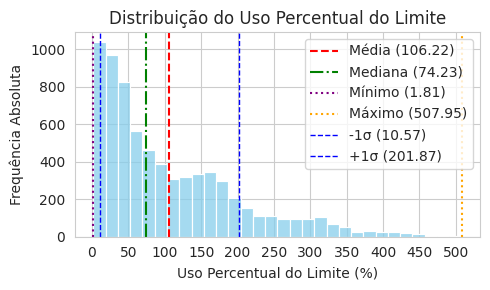

In [ ]:
coluna = 'uso_percentual_limite'
titulo = 'Distribuição do Uso Percentual do Limite'

figura, eixo = plt.subplots(figsize=(5, 3))

# Histograma
sns.histplot(x=coluna, data=df_ajustado_final, stat='count', bins=30, ax=eixo, color='skyblue')

# usando as fómulas do pandas para calcular média, mediana, etc.
media = df_ajustado_final[coluna].mean()
mediana = df_ajustado_final[coluna].median()
minimo = df_ajustado_final[coluna].min()
maximo = df_ajustado_final[coluna].max()
desvio = df_ajustado_final[coluna].std()

# indicador na linha da média, mediana, etc.
eixo.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Média ({media:.2f})')
eixo.axvline(mediana, color='green', linestyle='-.', linewidth=1.5, label=f'Mediana ({mediana:.2f})')
eixo.axvline(minimo, color='purple', linestyle=':', linewidth=1.5, label=f'Mínimo ({minimo:.2f})')
eixo.axvline(maximo, color='orange', linestyle=':', linewidth=1.5, label=f'Máximo ({maximo:.2f})')

# linhas do desvio padra
eixo.axvline(media - desvio, color='blue', linestyle='--', linewidth=1, label=f'-1σ ({media-desvio:.2f})')
eixo.axvline(media + desvio, color='blue', linestyle='--', linewidth=1, label=f'+1σ ({media+desvio:.2f})')

# titulos e labels
eixo.set(title=titulo, xlabel='Uso Percentual do Limite (%)', ylabel='Frequência Absoluta')

# espaçamento
eixo.set_xticks(range(0, int(maximo)+1, 50))

eixo.legend()

plt.tight_layout()
plt.show()


O que podemos observar do gráfico do histograma acima.


🔸🔸 **Mínimo (1.81%)**:

O menor valor de uso percentual é bem baixo, mostrando que há cliente que praticamente não usou o limite do cartão.

🔸🔸 **1º quartil (q1 = 30.43%)**:

25% dos clientes usaram até 30.43% do limite. Isso mostra um grupo considerável de clientes com uso muito baixo do crédito.

🔸🔸 **Mediana (q2 = 74.23%)**:

Metade dos clientes usou até 74.23% do limite. Como a mediana é menor que a média, isso indica que a distribuição é assimétrica à direita (tem valores muito altos puxando a média).

🔸🔸 **3º quartil (q3 = 158.34%)**:

75% dos clientes usaram até 158.34% do limite. Isso já sugere que um quarto dos clientes ultrapassou em mais de 58% o limite disponível.

🔸🔸 **Máximo (507.95%)**:

O maior valor é absurdo: um cliente gastou mais de 5 vezes o limite do cartão. Esse é um outlier extremo e ajuda a puxar tanto a média quanto o desvio padrão para cima.

🔸🔸 **Média (106.22%)**:

Em média, os clientes gastaram acima de 100% do limite. Isso significa que, como conjunto, os clientes tendem a ultrapassar o crédito concedido.

🔸🔸 **Desvio padrão (95.65%)**:

O desvio padrão é alto. Ele mostra que há grande variabilidade: alguns clientes gastam quase nada, outros ficam próximos do limite, e outros gastam múltiplas vezes acima dele.

*   **Média - 1σ = 10.57%**: Uma parte dos clientes usa quase nada.
*   **Média + 1σ = 201.87%**: Já outros chegam a gastar o dobro do limite ou mais.






Agora podemos começar a relacionar as informações da métrica *uso_percentual_limite* com outras métricas.



### Visualização categórica

 Vamos manter no radar que queremos analisar a distribuição do *uso_percentual_limite* por



1.   Variáveis categóricas: escolaridade, estado civil, salario anual e tipo de cartão;
2.   Variáveis numéricas: idade, dependentes, meses de relacionamento, quantidade de produtos, iterações nos últimos 12 meses, meses inativos nos últimos 12 meses, limite de crédito, valor de transações nos últimos 12 meses e  quantidade de transações nos últimos 12 meses


e se existe uso excessivo do limite em algum grupo específico.

#### Aspectos gerais dos dados

Antes de iniciarmos a análise dos dados relacionando variáveis categóricas com numérica, é importante observar a proporção com que cada dado, para cada categoria, se distribui. Para isso, vejamos os gráficos de barras abaixo, que indicam essa distribuição (também seria possível ver essa quebra usando gráfico de pizza).

In [ ]:
# contagem por escolaridade
contagem_escolaridade = df_ajustado_final.groupby('escolaridade').size().reset_index(name='contagem')
# groupby() agrupa as linhas do df com base nos valores unicos da coluna de escolaridade (agrupa tudo o que é Mestrado , tudoi o que é doutorado....)
#.size() conta o tamanho, ou num de linhas, de cada um dos grupos
# .reset_index(name='contagem') transforma os valores de 'sexo' em uma coluna do df
print("Contagem por Escolaridade:")
total_escolaridade = contagem_escolaridade['contagem'].sum()
contagem_escolaridade['percentual'] = (contagem_escolaridade['contagem'] / total_escolaridade * 100).round(2)
print(contagem_escolaridade)
print("\n" + "="*30 + "\n")

# contagem por estado civil
contagem_estado_civil = df_ajustado_final.groupby('estado_civil').size().reset_index(name='contagem')
print("Contagem por Estado Civil:")
total_estado_civil = contagem_estado_civil['contagem'].sum()
contagem_estado_civil['percentual'] = (contagem_estado_civil['contagem'] / total_estado_civil * 100).round(2)
print(contagem_estado_civil)

Contagem por Escolaridade:
          escolaridade  contagem  percentual
0            doutorado       789       11.14
1         ensino medio      1653       23.34
2            graduacao       844       11.92
3             mestrado      2591       36.59
4  sem educacao formal      1204       17.00


Contagem por Estado Civil:
  estado_civil  contagem  percentual
0       casado      3564       50.33
1   divorciado       569        8.04
2     solteiro      2948       41.63


Desses dados, podemos fazer algumas breves anotações:


*   36,59% das pessoas têm mestrado (a maior dentre todos os grupos), enquanto 11,14% têm doutorado (o menor dentre todos os grupos).
*   Mais de 50% das pessoas é casada, enquanto 8,04% é divorciada.

Também podemos ver uma representação gráfica da distribuição desses dados, como exibido nos gráficos abaixo. Só a título de curiosidade, dos dois gráficos abaixo fornecem o mesmo retorno usando métodos diferentes: `sns.countplot`e `sns.histplot`. Embora o retono seja o mesmo, os dois métodos não fazem a mesma coisa.


/tmp/ipython-input-4091416206.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')
/tmp/ipython-input-4091416206.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')


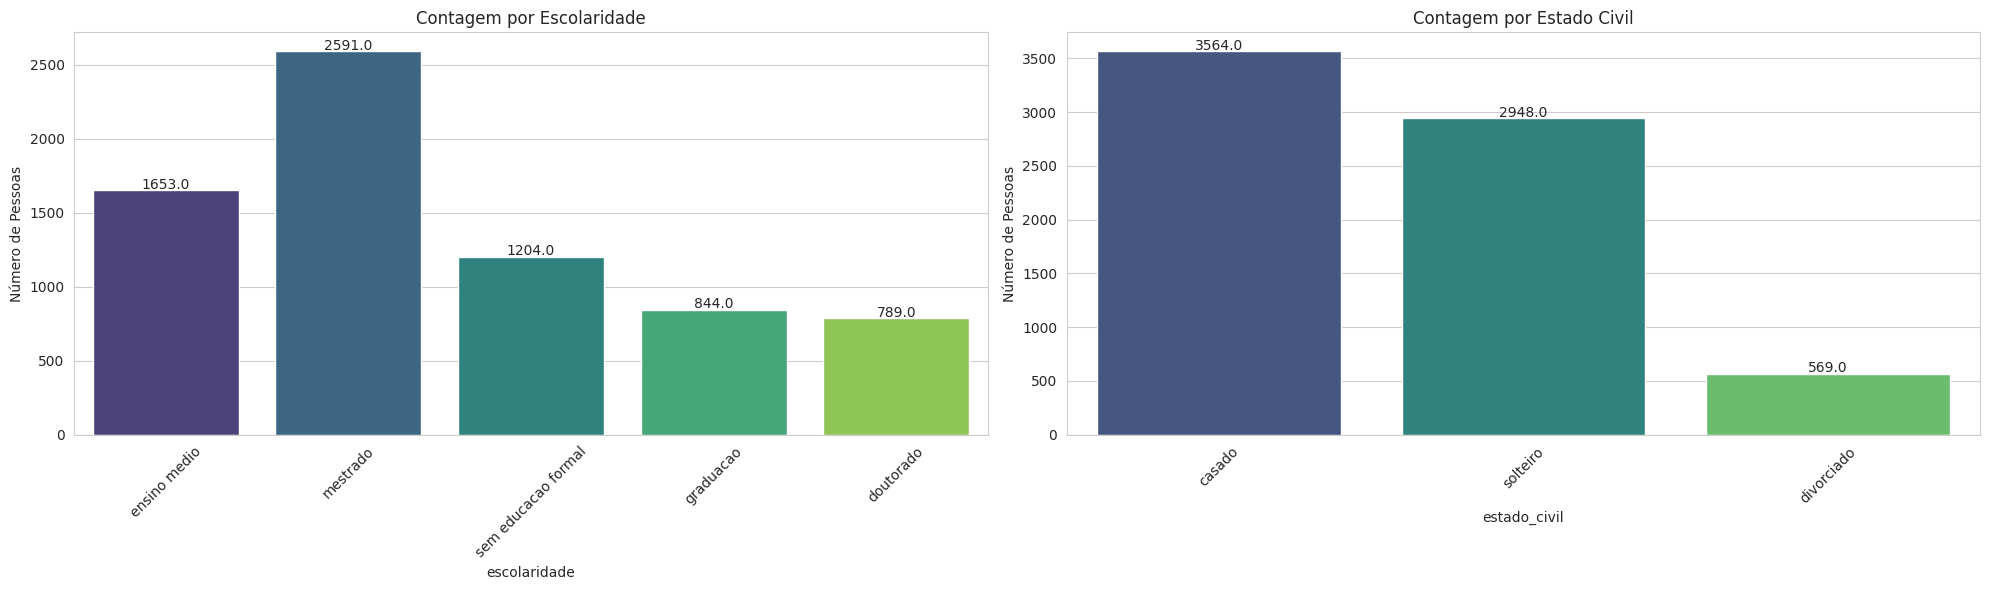

In [ ]:
# configura a figura com 2 subplots para cada variavel
figura, eixo = plt.subplots(1, 2, figsize=(20, 6))# plt.subplots(...) cria uma figura com 2 subgraficos (ou eixos) organizados em uma unica linha;
# O tamanho total da figura é definido como 20x6 polegadas. A funcaoo retorna a figura (o conteiner geral) e uma lista de eixo (um para cada subgrafico)

variaveis = ["escolaridade", "estado_civil"]
titulos = ["Contagem por Escolaridade", "Contagem por Estado Civil"]

for i, var in enumerate(variaveis):
    # sns.countplot() vai contar a frequencia de cada categoria
    sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')

    eixo[i].set_title(titulos[i])
    eixo[i].set_ylabel("Número de Pessoas")
    eixo[i].tick_params(axis="x", rotation=45)

    # vai adiciona as contagens/legendinhas de dados em cima de cada barra
    for p in eixo[i].patches:
        height = p.get_height()
        eixo[i].text(p.get_x() + p.get_width()/2., height + 10, height, ha="center")

#exibição
plt.tight_layout()
plt.show()

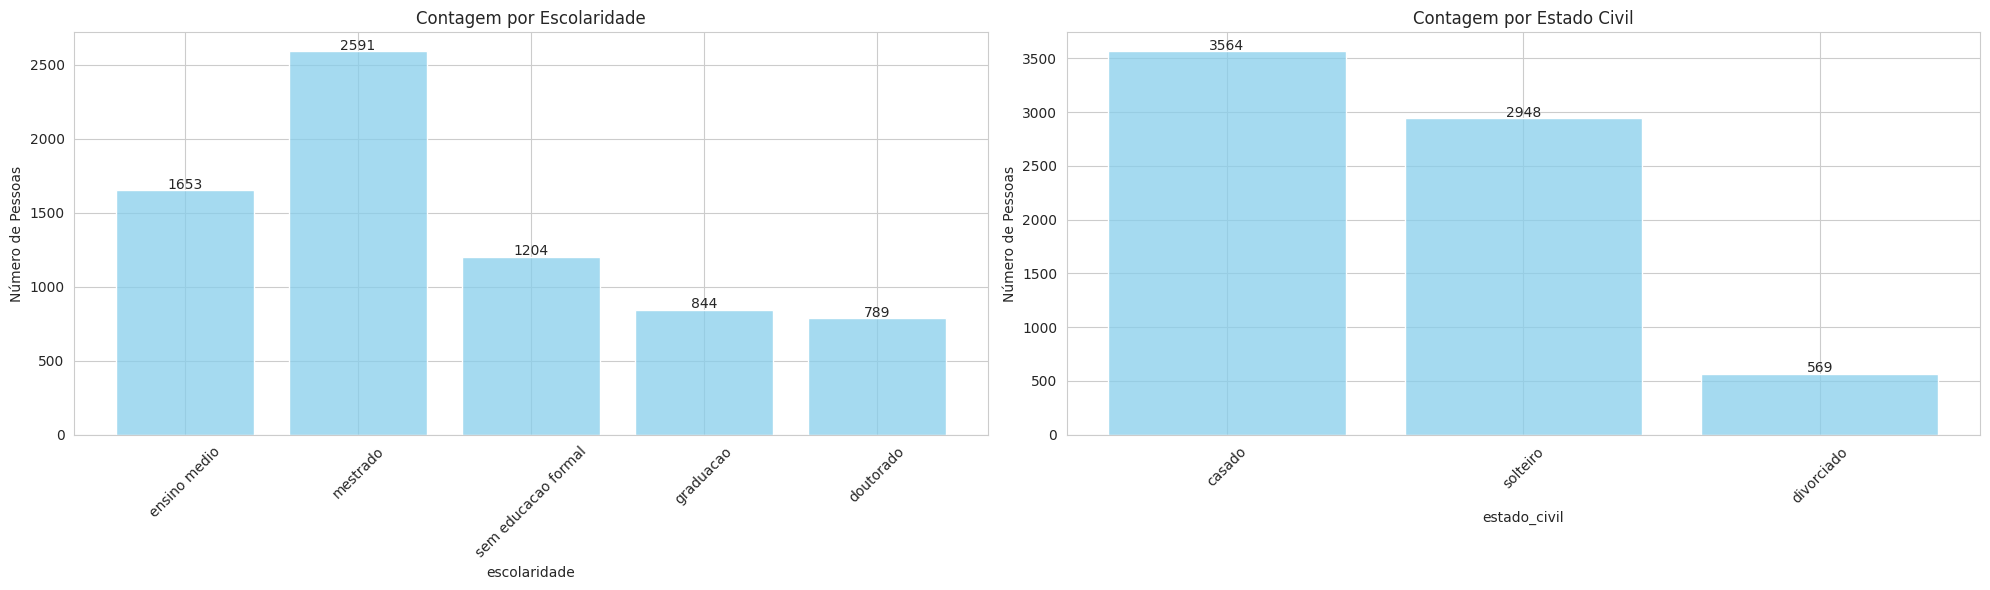

In [ ]:
# configura a figura com 2 subplots para cada variavel
figura, eixo = plt.subplots(1, 2, figsize=(20, 6))

variaveis = ["escolaridade", "estado_civil"]
titulos = ["Contagem por Escolaridade", "Contagem por Estado Civil"]

for i, var in enumerate(variaveis):
    # histplot no lugar de countplot, com discrete=True para tratar como categórico
    sns.histplot(
        x=var,
        data=df_ajustado_final,
        discrete=True, # opcional, já que só é necessário no histplot quando a variável é numérica discreta; se a coluna é tipo string/objeto, o próprio seaborn automaticamente trata como categórico
        ax=eixo[i],
        color='skyblue',
        shrink=0.8 # deixa espaço entre as barras , mas é opcional
    )

    eixo[i].set_title(titulos[i])
    eixo[i].set_ylabel("Número de Pessoas")
    eixo[i].tick_params(axis="x", rotation=45)

    # adiciona as contagens em cima das barras
    for p in eixo[i].patches:
        height = p.get_height()
        eixo[i].text(p.get_x() + p.get_width()/2., height + 10, int(height), ha="center")

#exibição
plt.tight_layout()
plt.show()



``sns.histplot``: Plota um histograma ou curva de densidade para variáveis numéricas. Divide os dados em intervalos (bins) e conta quantos valores caem em cada intervalo.

*   **Características:**

> *   Permite definir bins, binwidth e até discrete=True.
> *   Funciona bem para dados contínuos (altura, idade, salário).
> *   Pode mostrar densidade (stat="density") em vez de contagem absoluta.
> *   Pode sobrepor múltiplas distribuições (ex: hue="sexo" para idades).

*   **Quando usar:**

> *   Variáveis numéricas contínuas (idade, renda, altura, tempo).
> *   Variáveis discretas com muitos valores possíveis (ex: idades de 18 a 90).
> *   Quando você quer agrupar valores em intervalos para melhor visualização.
> *   Menos útil para variáveis categóricas puras (ex: estado civil), pois o agrupamento perde sentido.






``sns.counttplot``: Conta a frequência absoluta de categorias ou valores discretos em uma coluna. Cada valor único no eixo x (ou y) vira uma barra.

 *   **Características:**

> *   Usa value_counts por trás.
> *   O eixo x mostra valores distintos (ex: 0, 1, 2, 3 dependentes).
> *   Não há noção de intervalo: cada valor é mostrado separadamente.
> *   Sempre barras sólidas, não trabalha com bins.

 *   **Quando usar:**

> *   Variáveis categóricas nominais (ex: cor do carro, estado civil, tipo de produto).
> *   Variáveis discretas inteiras com poucos valores (ex: número de filhos, > nota de 1 a 5).
> *   Não indicado para variáveis contínuas ou com muitos valores distintos; o gráfico fica poluído (ex: idade contínua, altura em cm).



.............................................................................................................................................................................................................................


🔸 Exemplos práticos

>Dependentes (0, 1, 2, 3, 4, 5)

> *   countplot: mostra perfeitamente a distribuição (cada dependente é uma categoria); cria exatamente uma barra para cada categoria, já que conta classes.
> *   histplot: funciona também se usar discrete=True (o resultado é o mesmo). Como o histplot serve para dados contínuos ou discretos, ele vai funcionar como countplot. Agora se o número de dependentes for muit grande, ele vai precisar do discrete=True para se comportar como um countplot. Caso contrário (i.e., caso haja muitos dados discretos) e o dicrete=True não for usado, o histplot vai assumir que os dados são contínuos e dividir em intervalos/classes, em vez de atribuir barras exatas para cada dado, e ir agrupando.

>Idade (28, 29, 30, ... 65)

> *   countplot: cria uma barra para cada idade exata. Se o dataset for grande, o eixo fica poluído.
> *   histplot: permite agrupar (ex: de 5 em 5 anos), facilitando a leitura da distribuição; o histplot assume que os dados são contínuos e dividir em intervalos/classes, em vez de atribuir barras exatas para cada dado, e ir agrupando.



Por isso, no gráfico acima que usa `histplot`, o discrete=True é opcional. Teste rodar sem ele. Além disso, compare: os dois gráficos deram o mesmo retorno porque os dados são categóricas. Quando falrmos de variáveis numéricas, irei usar o gráfico de countplot mais uma vez e veremos o quão inconveniente é seu uso quando os dados são idades. Por isso, será mais recorrente o uso de histogramas, que permitem a criação desses agrupamentos/intervalos/classes de valores, evitando a poluição visual.

####Relacionando as variáveis

Como a variável *uso_percentual_limite* é numérica e as variáveis escolaridade, etc. são categóricas, vamos usar o gráfico de boxplot para analisar a relação entre as variáveis categóricas e a variável numérica *uso_percentual_limite*.


>💡 **Sobre boxplot**
>
> O boxplot tem as anatomia de uma caixa, ou bloco retangular, atravessada centralmente por um segmento vertical que tem extremidade delimitando seu início e fim. As extremidades inferior e superior desse segmento correspondem, respectivamente aos valores mínimo e máximo. Já a caixa (box) em si representa a dispersão central dos dados:
>
>🔹🔹 O limite inferior da caixa corresponde ao primeiro quartil (Q1), ou seja, 25% dos valores estão abaixo dele.
>
>🔹🔹 O limite superior da caixa corresponde ao terceiro quartil (Q3), isto é, 75% dos valores estão abaixo dele.
>
>🔹🔹 A linha interna, que divide a caixa, indica a mediana (Q2), ou ponto central da distribuição.
>
>Dessa forma:
>
>🔸 A altura (ou largura, dependendo da orientação do gráfico) da caixa mostra o intervalo interquartil (IQR = Q3 − Q1), que mede a variação dos 50% valores centrais.
>
>🔸 Os segmentos que “saem” da caixa (conhecidos como whiskers) se estendem até os valores mínimos e máximos dentro de um limite esperado, ou seja, são todos os pontos do segmento vertical que atravessa o box.
>
>🔸 Pontos fora desses limites são considerados outliers, ou seja, valores atípicos que se distanciam muito da maior parte dos dados. Só a título de curiosidade, uma forma de encontrar outilers é usando a fórmula
>
>```
>q3 + 1.5 * iqr,
>```
>de modo que qualquer valor acima desse é considerado um outlier superior, da mesma forma:
>```
>q3 - 1.5 * iqr,
>```
>qualquer valor acima desse é considerado um outlier inferior.
>
>
>Assim, o boxplot é útil porque permite visualizar de forma rápida a tendência central (mediana), a dispersão (IQR e amplitude total) e a presença de valores extremos.

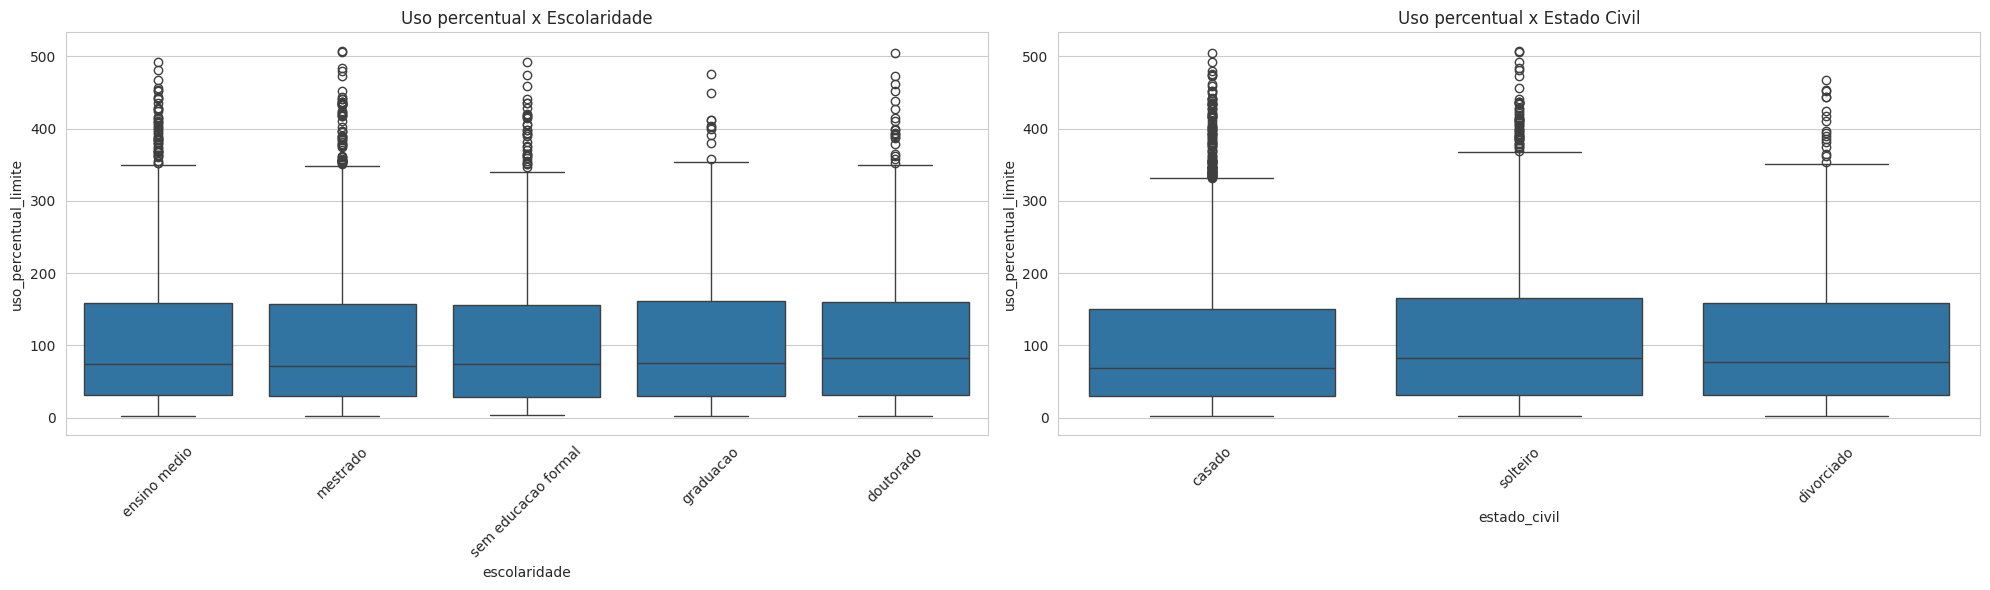

In [ ]:
figura, eixo = plt.subplots(1, 2, figsize=(20, 6)) # plt.subplots(...) cria uma figura com 2 subgraficos (ou eixos) organizados em uma unica linha;
# O tamanho total da figura é definido como 20x6 polegadas. A funcaoo retorna a figura (o conteiner geral) e uma lista de eixo (um para cada subgrafico)

# boxplot escolaridade
sns.boxplot(x="escolaridade", y="uso_percentual_limite", data=df_ajustado_final, ax=eixo[0])
eixo[0].set_title("Uso percentual x Escolaridade") # título do subgráfico
eixo[0].tick_params(axis="x", rotation=45)  # rotaciona as legendas das dimensões em 45 graus

# boxplot estado civil
sns.boxplot(x="estado_civil", y="uso_percentual_limite", data=df_ajustado_final, ax=eixo[1])
eixo[1].set_title("Uso percentual x Estado Civil")
eixo[1].tick_params(axis="x", rotation=45)

# exibição
plt.tight_layout()
plt.show()

De modo geral, parece que o uso percentual por escolaridade e estado civil não revela informações muito diferentes entre as dimensões, mas vejamos cada um dos casos. Suas diferenças ficam mais relevantes quando inserimos legendas de dados.

A versão abaixo trás um pouco mais de detalhes, inserindo legendas de dados nas posições mais relevantes do histograma: mínimo, q1, q2 (mediana), q3, máximo e outlier maior.

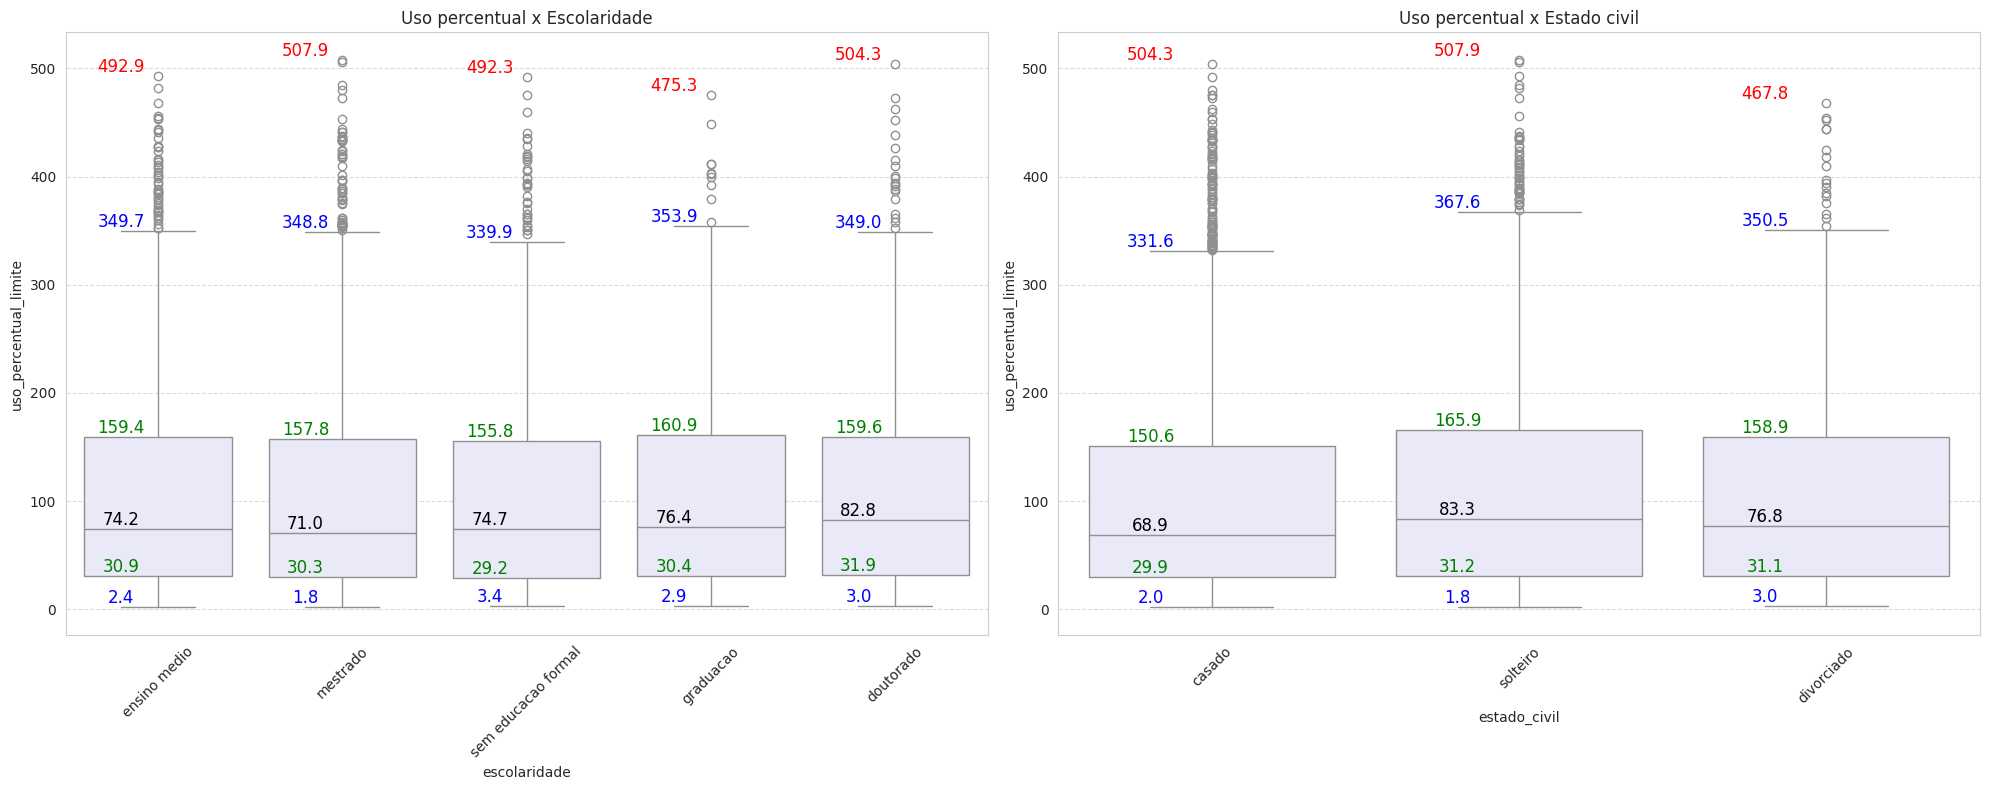

In [ ]:
# cria figura com 2 subplots/subgrafico lado a lado
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

# lista de variáveis e títulos que vão ser plotados lado a a lado
variaveis = ["escolaridade", "estado_civil"]
titulos = ["Uso percentual x Escolaridade", "Uso percentual x Estado civil"]

desloc_horiz = -0.2  # deslocamento horizontal das legendas min, max, quartis, etc.

for i, var in enumerate(variaveis):
    # boxplot principal
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, color="lavender", ax=eixo[i])
    eixo[i].set_title(titulos[i]) # título de cada subgráfico
    eixo[i].tick_params(axis="x", rotation=45) # rotação das legendas/rótulos do eixo
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7) # opcional, é só pra colocar uma linha de grade de fundo

    # pega os rótulos do eixo x (pra calcular os valores dos quartis, min, max, etc. mais adiante; aqui só faz a listagem)
    ordem_plot = [cat.get_text() for cat in eixo[i].get_xticklabels()]

    for j, cat in enumerate(ordem_plot):
        # tenta converter o rótulo para número; se não conseguir, mantém como está
        try:
            cat_val = float(cat)
        except ValueError:
            cat_val = cat

        # seleciona os valores correspondentes no df pra calcular os valores dos quartis, min, max, etc.
        valores = df_ajustado_final[df_ajustado_final[var] == cat_val]["uso_percentual_limite"].dropna()

        if len(valores) > 0: #sobre os valores listados, usa essas funções do pandas e começa a fazer os cálculos dos quantiles, min, max, pra usar nas legendinhas sobre os boxplots
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)
            iqr = q3 - q1
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()
            outlier_maximo = valores.max()

            posicao_x = j + desloc_horiz # só pra indicar onde essas legendinhas vão ficar; a que distancia horizontal; eu não quis deixar centralizado

            # adiciona as legendinhas com os valores sobre o gráfico
            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=12, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=12, color="black")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=12, color="blue")

            if outlier_maximo > whisker_superior: # só verifica se existe um ponto acima do limite normal (wisker_superior); o outlier_maximo é pra ser o maior valor real da amostra
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=12, color="red") # aqui sõa as orientações para escrever esse valorzinho sobre o gráfico

plt.tight_layout()
plt.show()


Só a título de curiosidade, note que o código logo abaixo permite que possamos ver quais são os valores máximo, mínimo, q1, mediana (q2) e q3, além de outliers dentre os valores de uso percentual do limite do cartão dividido em cada categoria:  entre ensino médio, mestrado, sem educação formal, graduação e doutorado, quando a categoria é escolaridade, e; casado, solteiro e divorciado, quando a categoria é estado civil.

Isso pode inclusive nos ajudar a ver se os dados indicados no gráfico estão corretos.

In [ ]:
# código de checagem manual dos dados do boxplot


def resumo_por_categoria(df, categorica_col, numerica_col):#retorna o resumo estatistico para cada categoria

    grupos = df.groupby(categorica_col)[numerica_col]# agrupa os dados do df pela coluna categoria e seleciona a coluna numerica
    resultados = {} # vai armazenas o resultado dos dados para cada categoria

    for cat, serie in grupos: # cat armazena o nome da variavel em cada categoria (F, ou M, ou...) e serie armazena a cloluna de dados numericos para essa categoria
        q1 = serie.quantile(0.25)
        q2 = serie.quantile(0.50)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        whisker_min = serie[serie >= (q1 - 1.5 * iqr)].min()
        whisker_max = serie[serie <= (q3 + 1.5 * iqr)].max()

        outliers = serie[(serie < (q1 - 1.5 * iqr)) | (serie > (q3 + 1.5 * iqr))] #aqui o operador ou | vai pegar todos os outliers (dados que estão fora do intercalo definido pelos whuiskers)

        resultados[cat] = {
            "Min": round(whisker_min, 2),
            "Q1": round(q1, 2),
            "Mediana (Q2)": round(q2, 2),
            "Q3": round(q3, 2),
            "Max": round(whisker_max, 2),
            "Outliers": list(outliers.round(2))
        }

    return pd.DataFrame(resultados).T #esse .T é só para exibir os dados de forma transposta; categorias sendo linhas e dados estatísticos nas colunas


#print("Resumo por SEXO:")
#print(resumo_por_categoria(df_ajustado_final, "sexo", "uso_percentual_limite"))

# resumo dos dados para cada categoria
print("\nResumo por ESCOLARIDADE:")
print(resumo_por_categoria(df_ajustado_final, "escolaridade", "uso_percentual_limite"))

print("\nResumo por ESTADO CIVIL:")
print(resumo_por_categoria(df_ajustado_final, "estado_civil", "uso_percentual_limite"))



Resumo por ESCOLARIDADE:
                      Min     Q1 Mediana (Q2)      Q3     Max  \
doutorado            2.96  31.93        82.85  159.59  349.03   
ensino medio         2.35  30.93        74.19   159.4  349.67   
graduacao            2.91  30.39        76.45  160.92  353.86   
mestrado             1.81  30.32        70.99  157.78  348.81   
sem educacao formal  3.44  29.24        74.68  155.81  339.86   

                                                              Outliers  
doutorado            [352.04, 462.21, 391.31, 379.06, 400.13, 388.1...  
ensino medio         [362.01, 355.68, 352.16, 370.67, 373.36, 384.7...  
graduacao            [379.67, 411.31, 391.87, 402.58, 475.27, 448.9...  
mestrado             [354.39, 361.79, 354.29, 357.1, 356.94, 352.9,...  
sem educacao formal  [350.89, 346.76, 361.48, 350.51, 362.71, 365.0...  

Resumo por ESTADO CIVIL:
             Min     Q1 Mediana (Q2)      Q3     Max  \
casado       2.0  29.86        68.87  150.58  331.62   
divorci

Vejamos que:


1.   **Escolaridade**:

*   A mediana (q2) do uso percentual de limite é bastante similar para todos os grupos, variando de 70.99% (mestrado) a 82.85% (doutorado). Isso sugere que, na média, o nível de escolaridade não é um fator forte para prever o uso de crédito.

*   Os quartis (q1 e q3) também se mantêm relativamente próximos, indicando que a dispersão dos dados é consistente entre os grupos.

*   Embora a maioria dos grupos tenha valores medianos abaixo de 100%, é importante notar a presença de outliers em todos eles, o que significa que, independentemente da escolaridade, **existe uma parcela de indivíduos que gasta bem acima do limite de crédito**.


2.   **Estado civil**:

*   Pessoas solteiras apresentam a maior mediana (q2) de uso percentual, de 83.3%. O quartil q3 para este grupo também é o mais alto, com 165.9%. Isso sugere que, como um grupo, as pessoas solteiras tendem a usar uma maior porcentagem de seu limite de crédito em comparação com os outros estados civis.

*   Pessoas casada têm a mediana mais baixa de uso percentual (68.87%). O quartil q3 de 150.58% é o menor entre os três grupos. Essa diferença pode indicar que pessoas casadas tendem a ser mais conservadoras no uso de crédito ou que há uma maior distribuição de renda e despesas dentro da união.

*   Pessoas divorciadas apresentam valores de mediana e quartis que ficam entre os grupos de solteiros e casados (mediana de 76.82% e q3 de 158.9%). Isso sugere que o padrão de uso de crédito desse grupo não difere drasticamente dos outros.

* Em resumo, a análise dos dados sugere uma possível tendência de que pessoas solteiras utilizam uma parcela maior de seus limites de crédito, enquanto pessoas casadas mostram um padrão de uso mais moderado. A presença de outliers em todos os grupos de estado civil demonstra, mais uma vez, que há uma parcela de indivíduos que gasta muito acima do limite, independentemente do seu estado civil.


De qualquer forma, tanto no caso da Escolaridade quanto no caso do Estado civil, não temos dados que manifestem de forma expressamente significativa (conclusiva) se há algum excesso de uso do cartão em algum desses dois grupos.

### Visualização numérica

Agora vamos analisar o uso percentual do limite do cartão em variáveis numéricas: dependentes, meses de relacionamento, qtd de produtos, iterações 12m, meses inativo 12m, limite crádito, valor transações 12m e qtd transações 12m. Como são 8 variáveis, vou montar blocos com gráficos de duas em duas variáveis para facilitar a visualização.

O comando logo abaixo é apenas para relembramos esses dados (só lembrando que estamos ignorando as colunas default e id da análise, porque não são relevantes para a a análise).

In [ ]:
df_ajustado_final.drop(['id', 'default'], axis=1).select_dtypes('number').head(n=5)

,idade,dependentes,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m,uso_percentual_limite
0,45,3,39,5,3,1,12691.51,1144.90,42,9.02
1,49,5,44,6,2,1,8256.96,1291.45,33,15.64
2,51,3,36,4,0,1,3418.56,1887.72,20,55.22
4,40,3,21,5,0,1,4716.22,816.08,28,17.30
5,44,2,36,3,2,1,4010.69,1088.07,24,27.13


#### **Idade e dependentes**

Vamos iniciar com esses dois tópicos.


Só para continuidade e fazendo uma breve conexão com o assunto, vamos só retomar uma representação gráfica que usamos no bloco anterior (Visualização categórica) para vermos a distribuição dos dados por idades e dependentes: vamos usar o `countplot`e o `histplot`.

/tmp/ipython-input-2417180628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')
/tmp/ipython-input-2417180628.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')


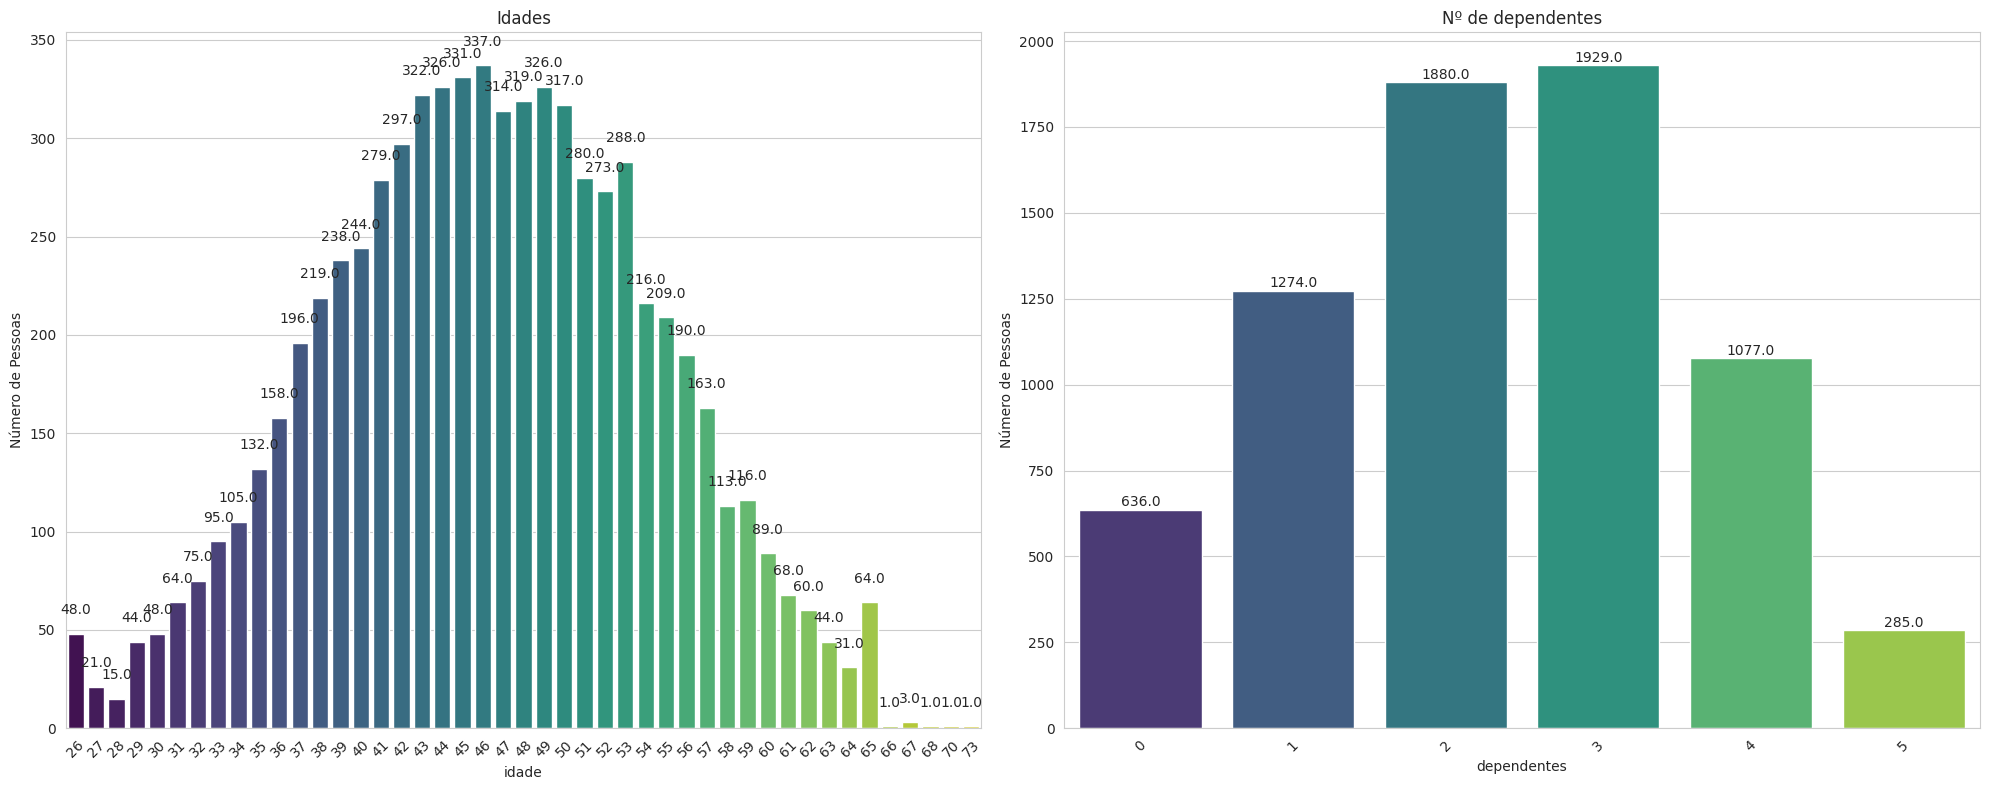

In [ ]:
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

variaveis = ["idade", "dependentes"]
titulos = ["Idades", "Nº de dependentes"]


for i, var in enumerate(variaveis):
    sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')

    eixo[i].set_title(titulos[i])
    eixo[i].set_ylabel("Número de Pessoas")
    eixo[i].tick_params(axis="x", rotation=45)

    # vai adiciona as contagens/legendinhas de dados em cima de cada barra
    for p in eixo[i].patches:
        height = p.get_height()
        eixo[i].text(p.get_x() + p.get_width()/2., height + 10, height, ha="center")

plt.tight_layout()
plt.show()

Veja que o `countplot`, como esperado, não é tão adequado para o caso em que temos um número grande de variáveis discretas, já que ele fica bem poluído (caso do gráfico de idades).

Agora abaixo usei o histograma de forma direta para a variável dependentes, enquanto que para idades precisei inserir de forma mais mecânica limites para que o centro de cada bin/barra ficasse na mesma direção vertical que o número do eixo horizontal. Veja que para dependentes, que tem uma quantidade menor de números, de fato, o `countplot`é mais interessante. Mas para o caso de idade, é melhor usar o histograma, que cria agrupamentos/classes dos grupos de dados para cada idade - no nosso caso, estão em grupos de 2 em 2 idades

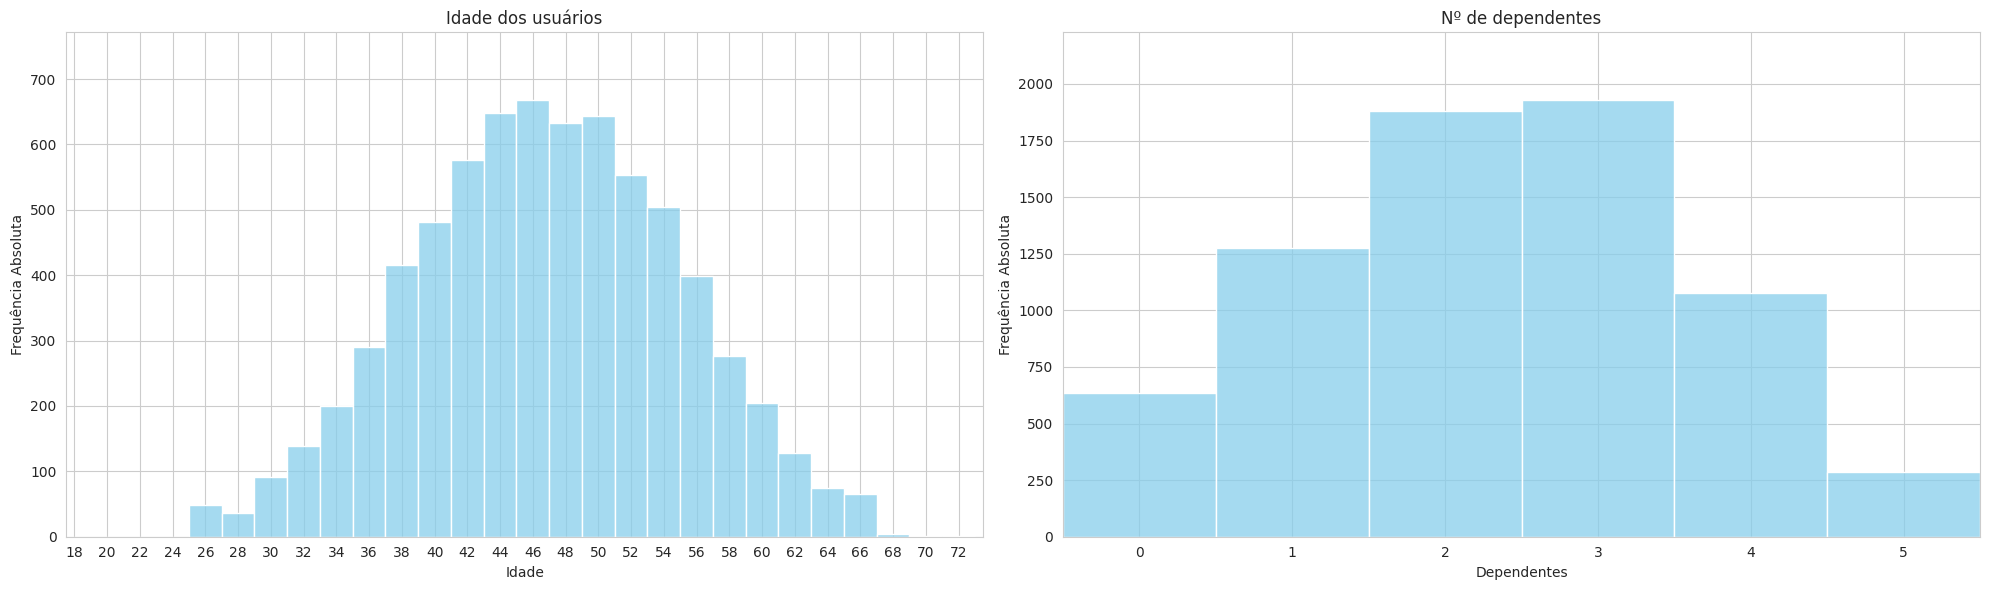

In [ ]:
# usei o mesmo código da seção anterior, só mudei praticamente as variaveis
import numpy as np # vou importar para criar as bordas dos intervalos e centralizar nos números das legendas do eixo x
variaveis = ['idade', 'dependentes']
titulos = ["Idade dos usuários", "Nº de dependentes"]

figura, eixos = plt.subplots(1, 2, figsize=(20,6))

for i, coluna in enumerate(variaveis):
    ax = eixos[i]

    if coluna == "dependentes":
        # variável discreta: centraliza com discrete=True
        sns.histplot(x=coluna,data=df_ajustado_final,stat='count',discrete=True,ax=ax,color='skyblue')
        # ticks nos inteiros (centro das barras)
        max_dep = int(df_ajustado_final['dependentes'].max())
        ax.set_xticks(range(0, max_dep + 1))
        ax.set_xlim(-0.5, max_dep + 0.5)

    else:
        # idade: definimos bins de forma explícita para garantir centros nos inteiros
        binwidth = 2 # largura do bin/barra
        min_age = 18 # começando em 18 anos
        max_age = int(df_ajustado_final['idade'].max())

        # bordas dos bins: comece em min_age - binwidth/2 para centralizar; foi para essa etapa que puxei o numpy
        edges = np.arange(min_age - binwidth/2, max_age + binwidth/2 + 1e-6, binwidth)
        # o np.arange gera as bordas exatas dos bins/intervalos. Já o centers calcula os pontos médios,para alinhar os ticks do eixo x com o centro de cada barra.

        # centers (centros dos bins) são as posições para colocar os ticks
        centers = (edges[:-1] + edges[1:]) / 2

        # desenha histograma usando os bordas/edges calculados
        sns.histplot(x=coluna, data=df_ajustado_final, bins=edges, ax=ax, color='skyblue', stat='count')

        # coloca ticks nos centros, para reduzir/concentrar o espalhamento dos centros
        # aqui fica um tick a cada 2 centros para não poluir
        tick_step = 1  # dá pra colocar 2, se quiser putar a cada 4 centros, etc
        ax.set_xticks(centers[::tick_step])
        ax.set_xlim(min_age - 0.5, max_age + 0.5)

    # rótulos e título
    ax.set_title(titulos[i])
    ax.set_xlabel(coluna.capitalize())
    ax.set_ylabel('Frequência Absoluta')

    # folga do euxo y; opcional
    _, max_y_f = ax.get_ylim()
    ax.set_ylim(0, max_y_f * 1.1)

plt.tight_layout()
plt.show()


Também seria possível usar o `histplot` só com o seaborn e sem forçar explicitamente a delimitação/fronteiras/limites/bordas de cada bin/barra, mas o eixo vertical que passa pelo centro de cada bin/borda poderia não coincidir com a posição do número no eixo horizontal, como visto abaixo. O código acima força esse match.

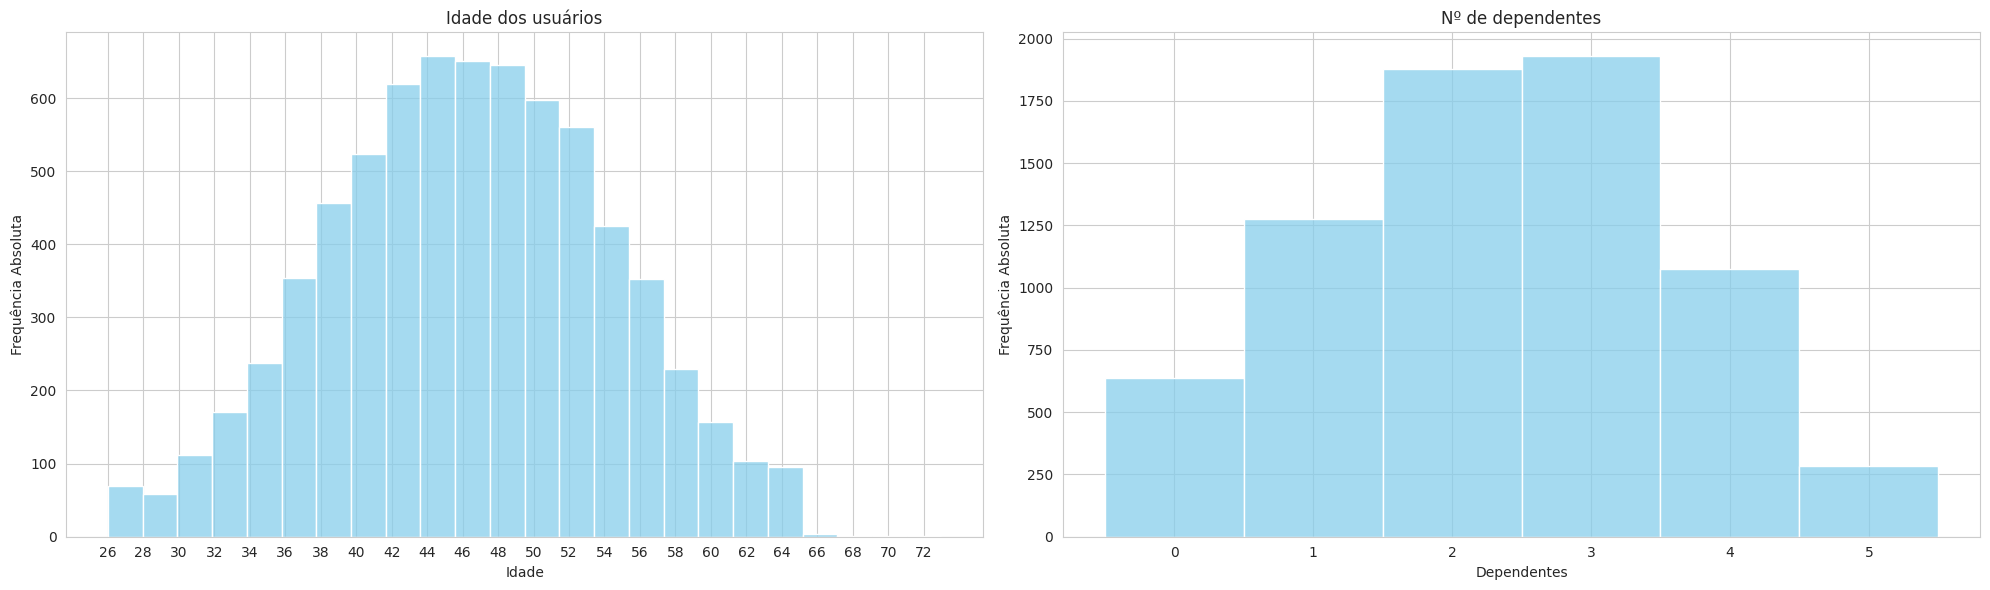

In [ ]:
#usando só o seaborn

variaveis = ['idade', 'dependentes']
titulos = ["Idade dos usuários", "Nº de dependentes"]

figura, eixos = plt.subplots(1, 2, figsize=(20,6))

for i, coluna in enumerate(variaveis):
    ax = eixos[i]

    if coluna == "dependentes":
        sns.histplot(
            x=coluna,
            data=df_ajustado_final,
            stat='count',
            discrete=True,
            ax=ax,
            color='skyblue'
        )
        # ticks nos inteiros
        max_dep = int(df_ajustado_final['dependentes'].max())
        ax.set_xticks(range(0, max_dep + 1))

    else:
        sns.histplot(
            x=coluna,
            data=df_ajustado_final,
            stat='count',
            binwidth=2,  # faixas de 2 anos
            ax=ax,
            color='skyblue'
        )
        # força ticks só nos inteiros do range observado
        min_age = int(df_ajustado_final['idade'].min())
        max_age = int(df_ajustado_final['idade'].max())
        ax.set_xticks(range(min_age, max_age+1, 2))  # ticks de 2 em 2

    ax.set_title(titulos[i])
    ax.set_xlabel(coluna.capitalize())
    ax.set_ylabel("Frequência Absoluta")

plt.tight_layout()
plt.show()

Antes de comentar sobre os gráficos, vou adicionar um describe() abaixo para comentar com mais detalhes.




In [ ]:
df_ajustado_final[['idade', 'dependentes']].describe()

,idade,dependentes
count,7081.000000,7081.000000
mean,46.347691,2.337805
std,8.041225,1.291649
min,26.000000,0.000000
25%,41.000000,1.000000
50%,46.000000,2.000000
75%,52.000000,3.000000
max,73.000000,5.000000


Analisando os gráficos e os dados do describe(), vemos que:



🔸Sobre as idades:
*   A média de idade é 46,35 anos, e o desvio padrão é de 8,04 anos.
*   Ou seja, maior parte dos usuários está concentrada na faixa [38 – 54 anos], ou seja, dentro de 1 desvio padrão da média.
*   Visualmente, no histograma, vemos que a maioria dos usuários se concentra entre 40 e 50 anos, confirmando o que os números mostram.
*   A idade mínima registrada é 26 anos e a máxima é 73 anos, mas usuários nessas pontas são minoria — aparecem apenas nas caudas da distribuição.


🔸Sobre os dependentes:
*   A média é de 2,34 dependentes, com desvio padrão de 1,29.
*   Isso indica que a maioria das pessoas tem entre 1 e 3 dependentes, já que 1 desvio padrão em torno da média cobre aproximadamente essa faixa.
*   O gráfico confirma: as barras mais altas estão em 2 e 3 dependentes, seguidas de perto por 1 dependente.
*   Os extremos (0 ou 5 dependentes) são bem menos frequentes — aparecem, mas representam uma fração pequena da base de usuários.


Agora avaliando como se dá o uso percentual do limite para essas métricas.

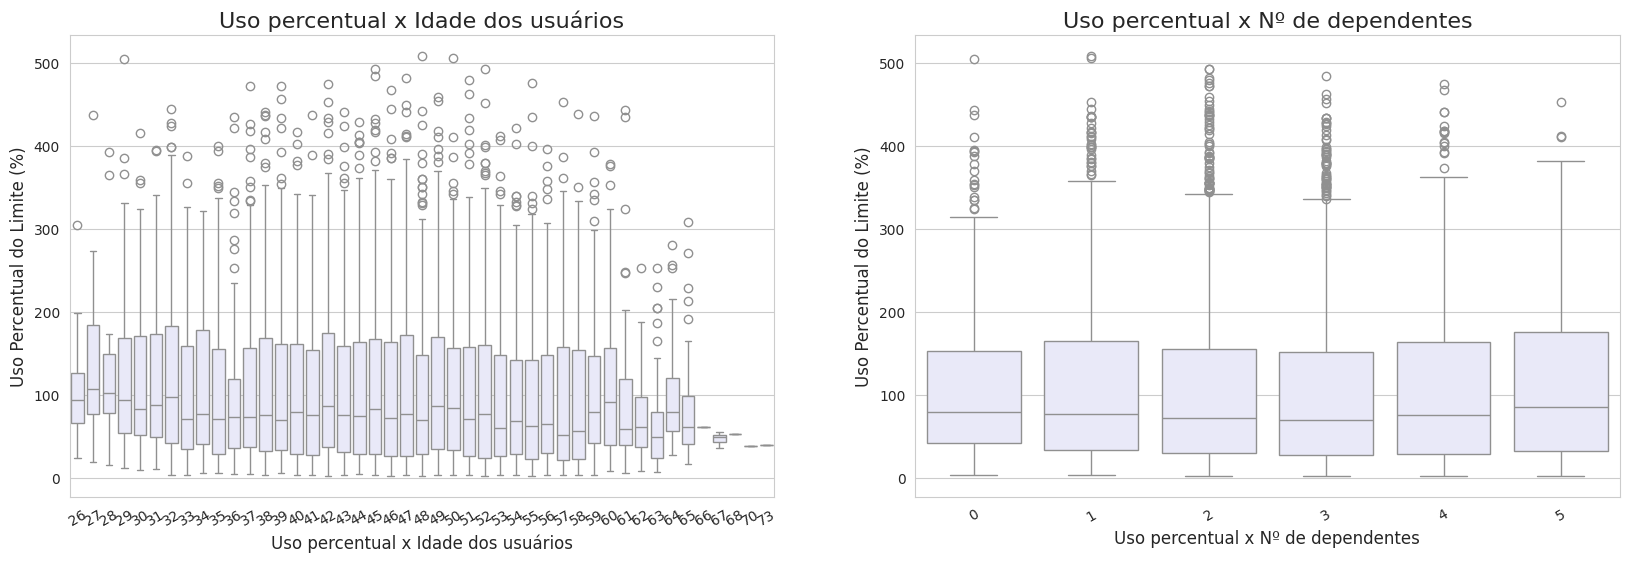

In [ ]:
variaveis = ['idade', 'dependentes']
titulos = ["Uso percentual x Idade dos usuários", "Uso percentual x Nº de dependentes"]

figura, eixos = plt.subplots(1, 2, figsize=(20,6))

for i, coluna in enumerate(variaveis):
    ax = eixos[i]
    sns.boxplot(data=df_ajustado_final, x=coluna, y='uso_percentual_limite', color="lavender", ax=ax)
    ax.set_title(titulos[i], fontsize=16)
    ax.set_xlabel(titulos[i], fontsize=12)
    ax.set_ylabel('Uso Percentual do Limite (%)', fontsize=12)
    ax.tick_params(axis='x', rotation=30)  # para girar os rotulos do eixo x


Mas note que caímos sobre um problema paracido com o  que que vimos acima, usando os gráficos de countplot e histplot, já que temos uma grande quantidade de idades. Nesse caso, vamos precisar agrupar algumas idades em blocos. Além disso, vou começar com a idade 26, porque, como visto pelo histograma acima e pelo describe(), só começamos a ter dados a partir de 26 anos.

Para fazer esse fatiamento/agrupamento, vou usar o método `pd.cut()` para fatiar/agrupar em uma quantidade que vamos poder indicar, vou atribuir à cada grupo uma espécie de rótulo e, depois, criar uma coluna no data frame em que as entradas vão indicar à que grupo pertence esse dado. Depois, na hora de fazer o gráfico, é só fazer em cima dos dados dessa coluna. Vou seguir dessa forma sempre que precisar fazer isso.

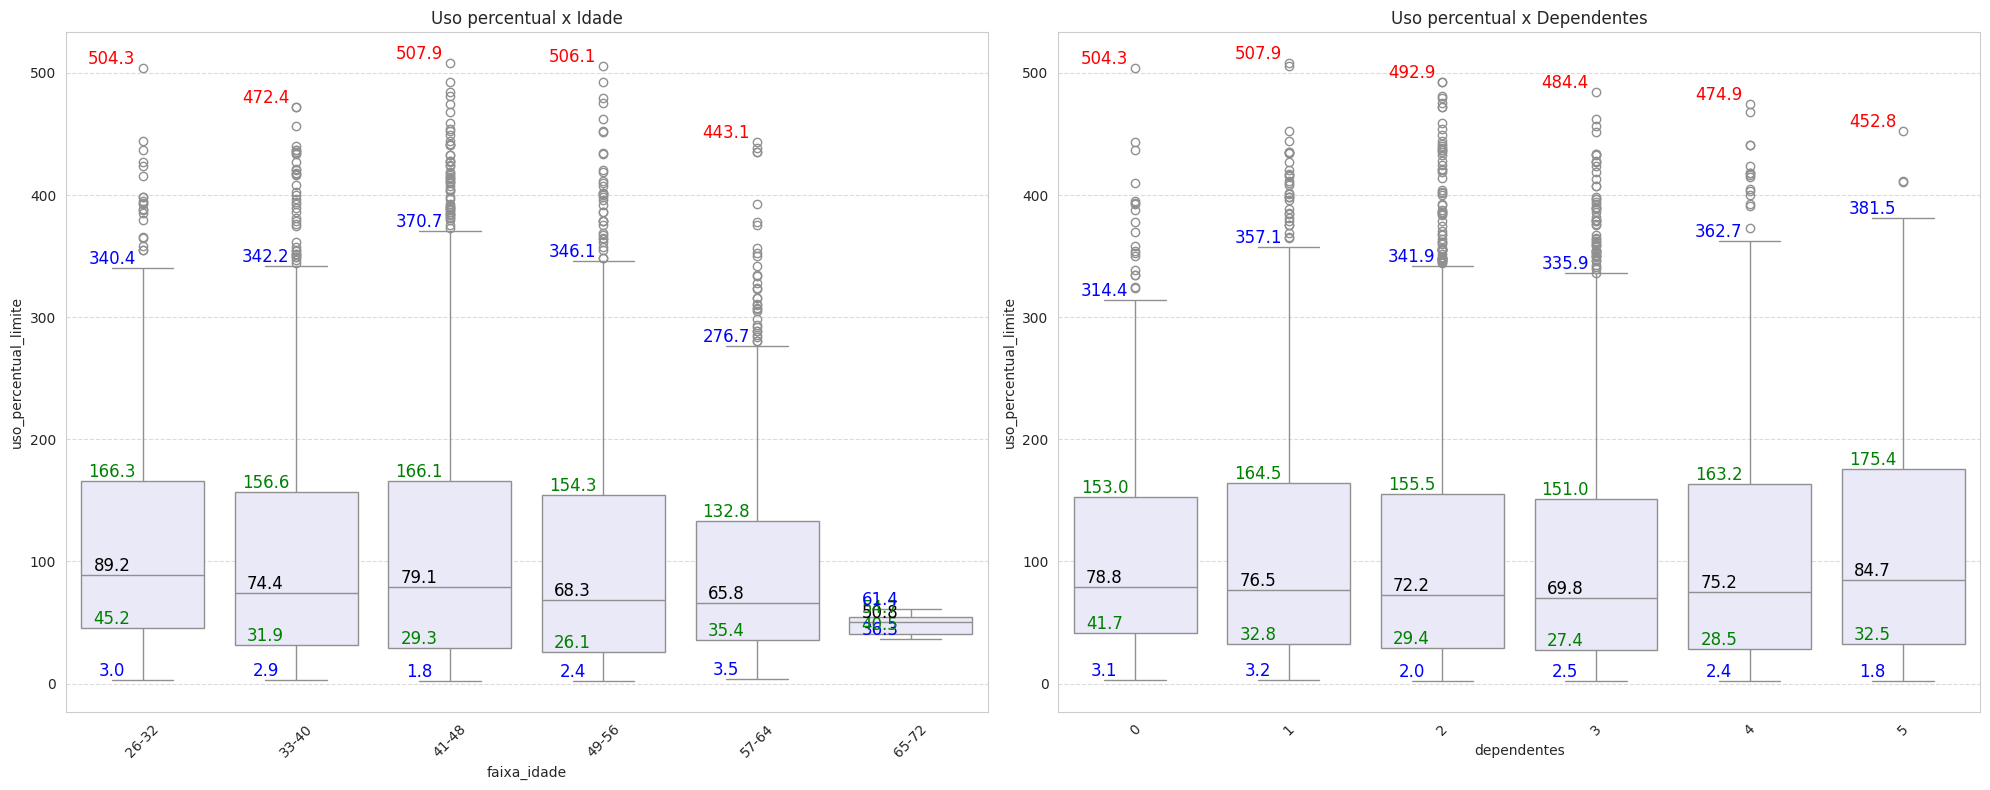

In [ ]:
# BLOCO 1: Criando as faixas de idade igualmente espaçadas e sem sobreposição

# Número de faixas desejadas
n_faixas = 6

# Define os limites mínimo e máximo das idades
idade_min = int(np.floor(df_ajustado_final["idade"].min()))
idade_max = int(np.ceil(df_ajustado_final["idade"].max()))

# Cria as bordas igualmente espaçadas (inclusive o limite máximo)
bins = np.linspace(idade_min, idade_max, n_faixas + 1)

# Cria as faixas com pd.cut
faixas_idade = pd.cut(df_ajustado_final["idade"], bins=bins, right=False, include_lowest=True)

# Cria rótulos limpos e inteiros
faixas_formatadas = [f"{int(left)}-{int(right-1)}" for left, right in zip(bins[:-1], bins[1:])]

# Atualiza as categorias
faixas_idades = faixas_idade.cat.rename_categories(faixas_formatadas)

# Adiciona a nova coluna ao DataFrame
df_ajustado_final["faixa_idade"] = faixas_idades



#--------------------------------------------------------------------------------------

# BLOCO 2: Criação dos boxplots
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

variaveis = ["faixa_idade", "dependentes"]
titulos = ["Uso percentual x Idade", "Uso percentual x Dependentes"]

desloc_horiz = -0.2

for i, var in enumerate(variaveis):
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, color="lavender", ax=eixo[i])
    eixo[i].set_title(titulos[i])
    eixo[i].tick_params(axis="x", rotation=45)
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7)

    ordem_plot = [cat.get_text() for cat in eixo[i].get_xticklabels()]

    for j, cat in enumerate(ordem_plot):
        try:
            cat_val = float(cat)
        except ValueError:
            cat_val = cat

        valores = df_ajustado_final[df_ajustado_final[var] == cat_val]["uso_percentual_limite"].dropna()

        if len(valores) > 0:
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)
            iqr = q3 - q1
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()
            outlier_maximo = valores.max()

            posicao_x = j + desloc_horiz

            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=12, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=12, color="black")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=12, color="blue")

            if outlier_maximo > whisker_superior:
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=12, color="red")

plt.tight_layout()
plt.show()

🔸Sobre as idades:
*   Há muitos outliers, especialmente para idades entre 25 e 60 anos, indicando que alguns usuários usam muito acima do limite médio.
*   A mediana do uso percentual do limite está em torno de 100%, com valores muito dispersos acima e abaixo.
*   Para idades mais avançadas (>65 anos), os dados parecem concentrar-se em um uso menor, com menos outliers.
*   Isso sugere que usuários mais jovens e de meia-idade tendem a ter maior variação no uso do limite, enquanto usuários mais velhos têm uso mais consistente (mais próximo da mediana).

🔸Sobre os dependentes:
*   Usuários com 0 a 5 dependentes têm medianas de uso similares, entre ~50 e 80%.
*   A dispersão é grande para todos os grupos, com muitos outliers acima de 300% do limite.
*   Isso indica que o número de dependentes não parece afetar muito a mediana do uso do limite, embora alguns usuários com dependentes usem muito acima do limite.


Em resumo, parece haver uma tendência de maior variabilidade no uso do limite para usuários mais jovens e de meia idade. Agora para o número de dependentes, não há  uma tendência claroa, já que a mediana se mantém aproximadamente no mesmo eixo entre diferentes números de dependentes. De modo geral, um ponto interessante é a grande quantidade de outliers, que se apresenta em quase todas as idades e em todos os números de dependentes.

Agora, em vez de analisar o comportamento de cada variável com o uso percentual, podemos usar o ``relplot`` para avaliar se há relação entre as duas variáveis:

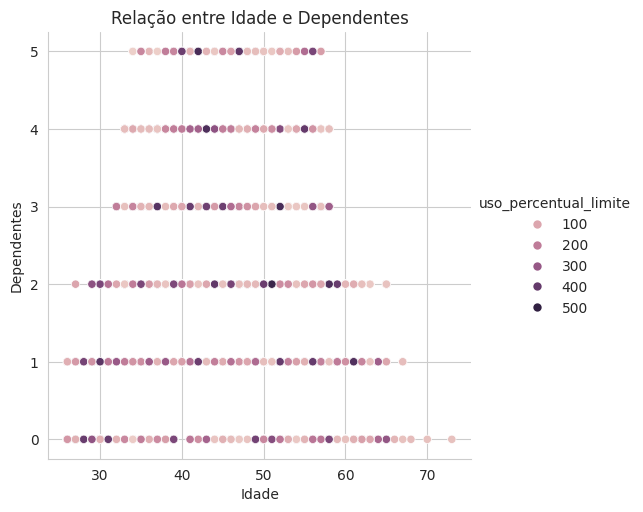

In [ ]:
f = sns.relplot(x='idade', y='dependentes', data=df_ajustado_final, hue='uso_percentual_limite')# hue coloca uma cor sobre a variável de interess
_ = f.set(title='Relação entre Idade e Dependentes', xlabel='Idade', ylabel='Dependentes') # o método set coloca títulos, etc

#note que esse código foi mais simples porque não tem nenhum for ou mais complexidade

Podemos avaliar que:

*   As concentrações mais fortes de idades estão entre 1 a 3 dependentes (o que já sabíamos do histograma anterior).
*   Quanto ao uso percentual, não parece haver uma relação forte entre idade, dependentes e uso do limite: em quase todas as idades e para diferentes números de dependentes aparecem pontos claros e escuros, sem um padrão ou tendência bem definida.
*   Usuários com 4 ou 5 dependentes são minoria, mas mesmo neles vemos a variação completa de cores; tanto baixo como alto uso do limite.
*   A maior concentração está mesmo nos usuários de 40 a 50 anos, com 2 a 3 dependentes, mas sem padrão visível de cor.

Sendo assim, podemos inferir que o uso percentual limite não apresenta um padrão nítido  em função da idade ou dependentes, visto que usuários de todas as faixas etárias e com diferentes dependentes apresentam tanto baixo quanto alto uso do limite. A faixa mais representativa é entre 40 e 50 anos, com 2 e 3 dependentes, mas, ainda assim, com grande variação no uso percentual limite (distribuição de pontos escuros e claros sem um padrão).

##### Só a título de curiosidade

É possível avaliar de forma analítica a correlação entre as duas métricas usando os cahamados coeficiente de correlação de Pearson e o coeficiente de correlação de Spearman. O coeficiente de correlação de Pearson mede relação linear, enquanto que o coeficiente de correlação de Spearman mede se a relação é crescente ou decrescente (monotônica) mesmo que não seja linear.


>💡 **Mais um pouco sobre coeficientes de correlação Pearson e de Spearman:**
>
>
>A **correlação de Pearson** mede o grau de associação linear entre duas variáveis numéricas contínuas. Em outras palavras, ela avalia: "À medida que X aumenta, Y aumenta (ou diminui) de forma proporcional?".
>
>A **correlação de Spearman** mede a associação monotônica entre duas variáveis, usando os postos (ranks) dos valores, não os valores em si. Em outras palavras, ela avalia: "Quando X aumenta, Y tende a aumentar (ou diminuir), de forma consistente — mesmo que não seja em linha reta?"

Para calcular de forma numérica (analítica) esses coeficientes, vamos usar o método ```.corr()``` do pandas, que calcula a matriz de correlação entre todas as colunas numéricas de um DataFrame (ou de um subconjunto dele), ou seja, ele vai calcular todas as correlações par a par entre essas colunas, gerando uma matriz simétrica. Nesse método, indicamos qual tipo de correlação desejamos calcular: pearson ou spearman.






In [ ]:
# selecionando apenas as variáveis de interesse
subset = df_ajustado_final[['idade', 'dependentes', 'uso_percentual_limite']]

# correlação de Pearson (linear)
correlacao_pearson = subset.corr(method='pearson')

# correlação de Spearman (ordem/ranks, útil para não-linearidades)
correlacao_spearman = subset.corr(method='spearman')

print("Correlação de Pearson:")
print(correlacao_pearson, "\n")

print("Correlação de Spearman:")
print(correlacao_spearman)


Correlação de Pearson:
                          idade  dependentes  uso_percentual_limite
idade                  1.000000    -0.128232              -0.049945
dependentes           -0.128232     1.000000              -0.002432
uso_percentual_limite -0.049945    -0.002432               1.000000 

Correlação de Spearman:
                          idade  dependentes  uso_percentual_limite
idade                  1.000000    -0.146673              -0.050166
dependentes           -0.146673     1.000000              -0.020675
uso_percentual_limite -0.050166    -0.020675               1.000000


No resultado acima, note que:


*   O valor 1.00 na diagonal é porque toda variável é perfeitamente correlacionada consigo mesma.
*   Os outros números são os coeficientes de correlação.




Para tornar essa mensuração analítica de forma mais paupável, podemos representar os valores da correlação de Pearson em um gráfico tipo Mapa de calor, ou Heatmap, que permite visualizar a intensidade e direção das relações.

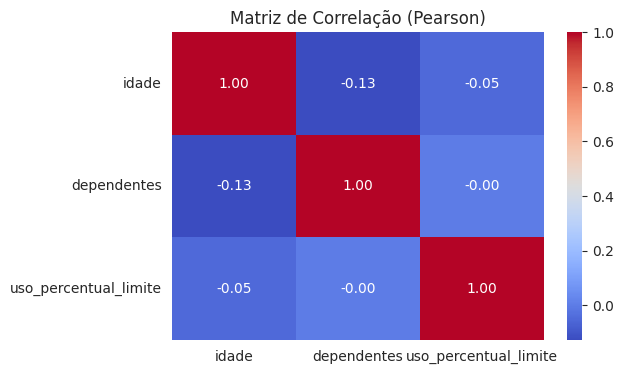

In [ ]:
# selecionando apenas as variáveis de interesse
subset = df_ajustado_final[['idade', 'dependentes', 'uso_percentual_limite']]

# matriz de correlação de Pearson
correlacao = subset.corr(method='pearson')

# heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação (Pearson)")
plt.show()


Note que, de fato, os valores de correlação de Pearson são os mesmos representados no mapa de calor.

Vamos interpretar o resultado da correlação de Pearson do mapa de calor. Os valores obtidos foram:



*   Idade x Dependentes = -0.13
*   Idade x Uso percentual do limite = -0.05
*   Dependentes x Uso percentual do limite = -0.04

Interpretando os resultados:


🔸Idade x Dependentes (-0.13):
>*   correlação negativa e fraca;
>*   em média, pessoas mais velhas tendem a ter um pouco menos dependentes, mas o efeito é muito pequeno. O próprio gráfico de dispersão (do relplot) confirma isso, exibindo dependentes em todas as idades.


🔸Idade x Uso percentual do limite (-0.05):
>*   correlação quase nula e negativa;
>*   a idade da pessoa praticamente não tem relaçã com quanto ela usa do limite do cartão.

🔸Dependentes x Uso percentual do limite (-0.04):
>*   correlação quase nula e negativa;
>*   ter dependentes não implica em usar mais ou menos do limite.



Portanto:
*   As correlações são todas próximas de 0, logo não há relação linear forte entre idade, dependentes e uso do limite.
*   Isso significa que, olhando só esses três fatores, o comportamento de uso do limite não pode ser explicado pela idade ou pelo número de dependentes.
*   O heatmap confirma o que vimos visualmente no relplot: os pontos estão espalhados sem uma tendência clara.


Podemos fazer o mesmo gráfico de calor para exibir o coeficiente de correlação de Spearman para avaliar se uma variável tende a aumentar (ou diminuir) de forma consistente quando a outra aumenta, mesmo que não seja linear.

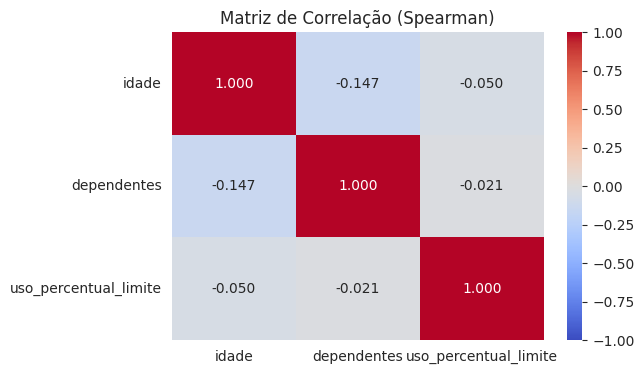

In [ ]:
# selecionando apenas as variáveis de interesse
subset = df_ajustado_final[['idade', 'dependentes', 'uso_percentual_limite']]

# matriz de correlação de Spearman
correlacao = subset.corr(method='spearman')

# heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlacao, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, cbar=True) # aqui coloquei o  vmin=-1, vmax=1, só pra realçar a diagonal e explicitar os outros valore
plt.title("Matriz de Correlação (Spearman)")
plt.show()


Vamos interpretar o resultado da correlação de Spearman do mapa de calor. Os valores obtidos foram:



*   Idade x Dependentes = -0.15
*   Idade x Uso percentual do limite = -0.05
*   Dependentes x Uso percentual do limite = -0.02

Ou seja, Spearman e Pearson praticamente coincidem, e quando as correlações Spearman forem parecidas com as de Pearson, significa que não há relações não lineares fortes escondidas; só quando houver diferenças perceptíveis (por exemplo: Pearson ~0 e Spearman ~0.3) é que pode ser um indicador de que existe alguma tendência monotônica que não é linear (um comportamento em "curva" ou uma saturação, por exemplo).

Portanto, isso indica que:


>🔸Não há relações não lineares fortes escondidas entre as variáveis.
>
>🔸As relações entre as variáveis são fracas em qualquer forma (linear ou monotônica).
>

Portanto, idade, dependentes e uso do limite são praticamente independentes entre si.

Agora vamos partir para a ana´lise das outras variáveis.

#### **Meses de relacionamento e quantidade de produtos**

Agora vamos avaliar essas duas métricas. Abaixo seguem os gráficos e o describe().

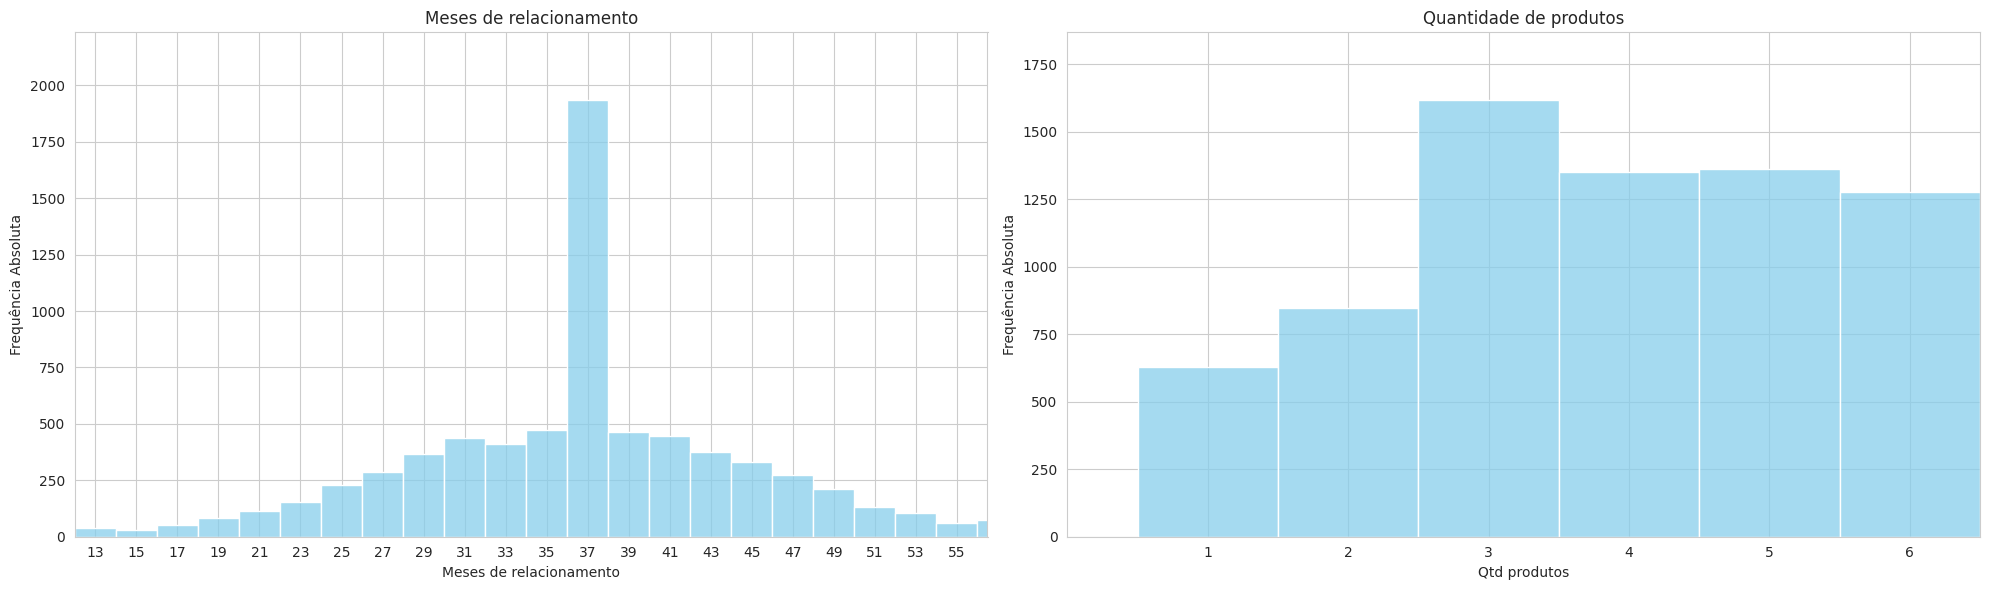

In [ ]:
variaveis = ['meses_de_relacionamento', 'qtd_produtos']
titulos = ["Meses de relacionamento", "Quantidade de produtos"]


figura, eixos = plt.subplots(1, 2, figsize=(20, 6))

for i, coluna in enumerate(variaveis):
    ax = eixos[i]

    if coluna == "qtd_produtos":
        # variável discreta: centraliza com discrete=True
        sns.histplot(x=coluna,data=df_ajustado_final,stat='count',discrete=True,ax=ax,color='skyblue')


        min_prod = int(df_ajustado_final['qtd_produtos'].min()) # pra ajustar o gráfico pra contagem do eixo inicial ter início no mín da variavel
        max_prod = int(df_ajustado_final['qtd_produtos'].max())
        ax.set_xticks(range(min_prod, max_prod + 1))
        ax.set_xlim(min_prod - 1, max_prod + 0.5)

    else:
        # variável contínua: meses de relacionamento
        binwidth = 2  # largura do bin/barra
        min_mes = int(df_ajustado_final['meses_de_relacionamento'].min())
        max_mes = int(df_ajustado_final['meses_de_relacionamento'].max())

        # cria bordas (edges) dos bins começando 1 menor que o mín da variavel
        edges = np.arange(min_mes - 1, max_mes + binwidth + 1e-6, binwidth)

        # calcula os centros dos bins
        centers = (edges[:-1] + edges[1:]) / 2

        # desenha histograma com as bordas calculadas
        sns.histplot(x=coluna,data=df_ajustado_final,bins=edges,ax=ax,color='skyblue',stat='count')

        # coloca ticks nos centros
        tick_step = 1
        ax.set_xticks(centers[::tick_step])
        ax.set_xlim(min_mes - 1, max_mes + 0.5)

    # rótulos e títulos
    ax.set_title(titulos[i])
    ax.set_xlabel(coluna.replace('_', ' ').capitalize())
    ax.set_ylabel('Frequência Absoluta')

    # folga no eixo y
    _, max_y_f = ax.get_ylim()
    ax.set_ylim(0, max_y_f * 1.1)

plt.tight_layout()
plt.show()


In [ ]:
df_ajustado_final[['meses_de_relacionamento', 'qtd_produtos']].describe()

,meses_de_relacionamento,qtd_produtos
count,7081.000000,7081.000000
mean,35.981359,3.819376
std,8.002609,1.544444
min,13.000000,1.000000
25%,31.000000,3.000000
50%,36.000000,4.000000
75%,40.000000,5.000000
max,56.000000,6.000000


🔸Sobre os meses de relacionamento:
*   O histograma mostra que a maior concentração de clientes está entre aproximadamente 31 e 40 meses, com um pico acentuado em 36-37 meses.
*   A média é 36 meses e a mediana também é 36 meses, indicando uma distribuição relativamente simétrica em torno do valor central.
*   O desvio padrão é 8 meses, o que sugere que a maioria dos clientes se concentra em um intervalo de aproximadamente 28 a 44 meses.
*   O mínimo é 13 meses e o máximo 56 meses, mostrando que há clientes com relacionamentos mais curtos ou mais longos, mas a maioria está concentrada no meio.

🔸Sobre as quantidades de produtos:
*   O histograma é discreto (como esperado), mostrando que a maioria dos clientes possui 3 a 5 produtos, com um pico em 3 produtos.
*   A média é 3,82 produtos e a mediana é 4 produtos, indicando uma leve assimetria à esquerda, ou seja, há mais clientes com maior número de produtos (4 a 6) do que com poucos (1 ou 2). Essa tendência é confirmada pelos dados de proporção abaixo: apenas 8,9% dos clientes possuem 1 produto e 12,0% possuem 2 produtos, enquanto 57% concentram-se entre 4 e 6 produtos.

In [ ]:
df_ajustado_final['qtd_produtos'].value_counts(normalize=True).sort_index()


,proportion
qtd_produtos,
1,0.088547
2,0.119757
3,0.228358
4,0.190651
5,0.192487
6,0.180201


*   O desvio padrão é 1,54, mostrando que a maioria dos clientes possui entre 2 e 5 produtos.



Em resumo, a base de clientes tende a permanecer na empresa por cerca de 3 anos (36 meses), e há uma concentração significativa de clientes nesse período e a base de clientes tende a manter 3 a 4 produtos.

Agora vamos plotar os boxplots, para avaliar a relação entre essas duas métricas e o uso do limite do cartão, respectivamente.

Note que, diferentemente do que fiz no boxplot de Idade e Dependentes, em que passei a lista de idades e dependentes, aqui vou solicitar ao código que crie os intervalos, ou seja, as faixas de meses de relacionamento e as de quantidade de produtos. Para isso, vamos usar o `pd.qcut()`

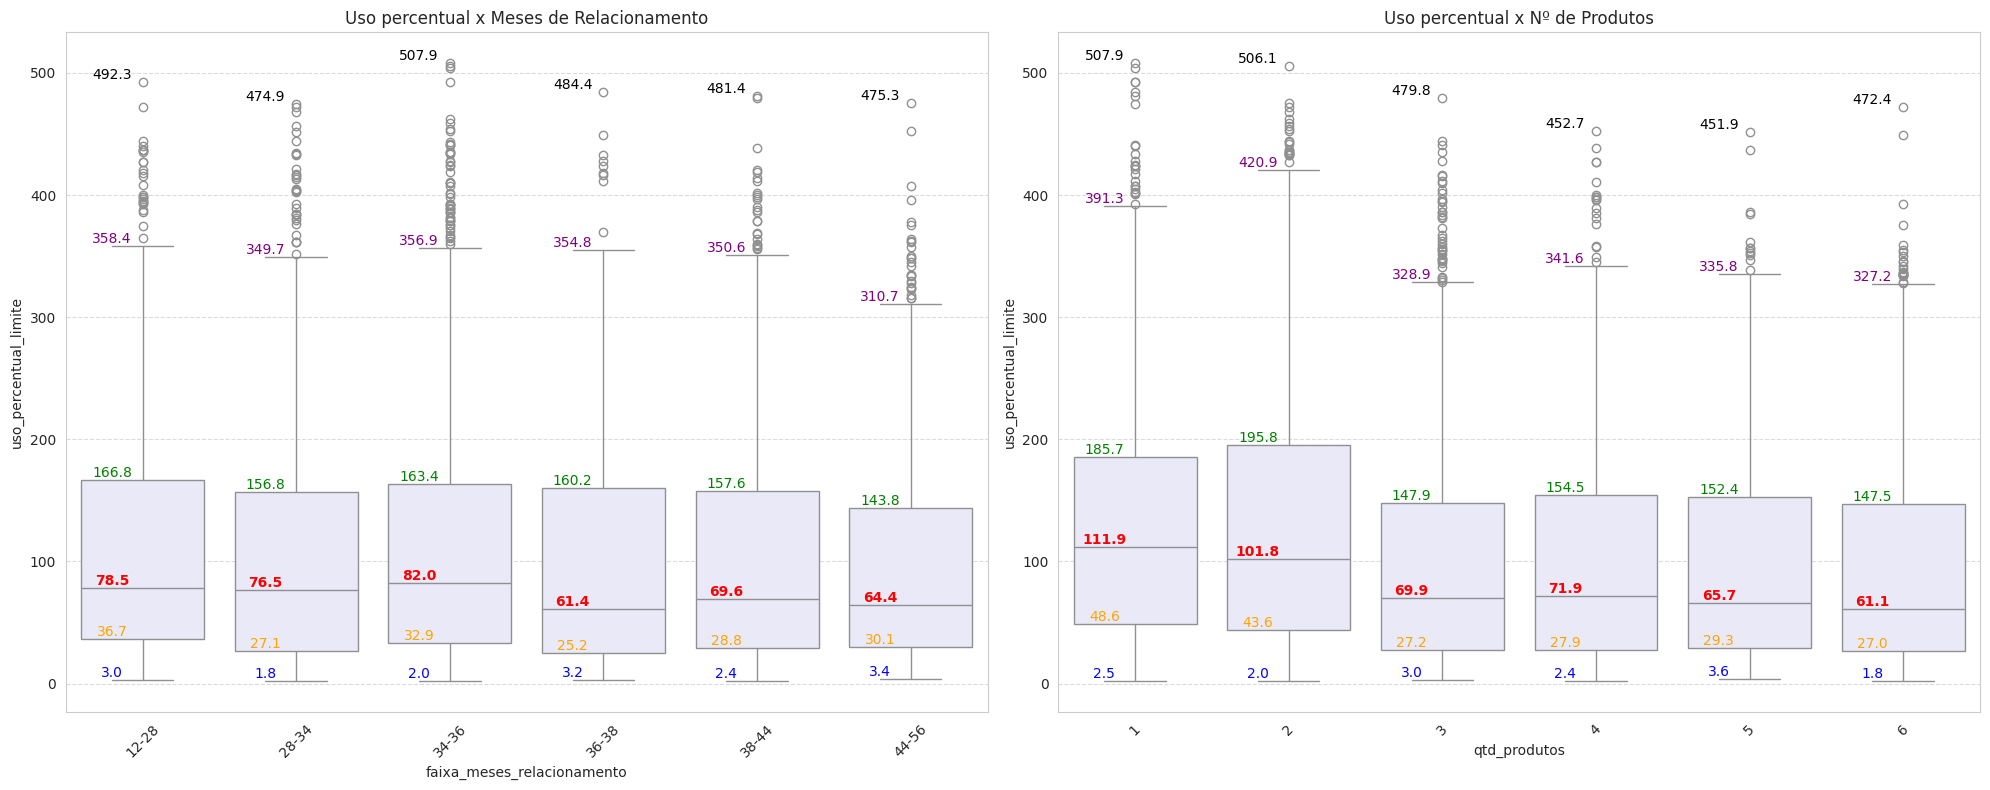

In [ ]:
# qcut cria intervalos/faixas de mesmo tamanho com base na distribuição dos dados;
# aqui vai ser necessário por conta dos meses de relacionamento; fizemos a mesma coisa em idades, mas no gráfico lá em cima, eu passei as idades em intervalos
# aqui vou solicitar que essa divisão/quebra/corte seja feito automaticamente, indicando o numero de faixas
faixas_meses = pd.qcut(
    df_ajustado_final["meses_de_relacionamento"],
    q=6,              # número de faixas
    duplicates="drop" # evita erro se houver menos bins distintos
)

# aqui vamos indicar que as legendas vão ser npúmeros inteiros
# cada categoria em faixas_meses.cat.categories retorna um Interval; cada intervalo representa os limites das faixas criadas pelo pd.cut(), mas com valores decimais
# para cirar rótulos/legendas limpas e sem casas decimais, vamos usar o np.floor() para arredondar o limite inferior para baixo e o
# np.ceil() para arredondar o limite superior para cima
faixas_formatadas = []
for intervalo in faixas_meses.cat.categories:
    # pega os limites (left, right) e arredonda para inteiro
    minimo = int(np.floor(intervalo.left))
    maximo = int(np.ceil(intervalo.right))
    faixas_formatadas.append(f"{minimo}-{maximo}")

# --- 3) Renomear as categorias (correção: usar rename_categories em vez de atribuir) ---
faixas_meses = faixas_meses.cat.rename_categories(faixas_formatadas)

# --- 4) Guardar no DataFrame ---
df_ajustado_final["faixa_meses_relacionamento"] = faixas_meses
#---------------------------------------------------------------------Daqui pra cima, ajustes para colocar os dados do eixo horizontal bonitinhos


figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

variaveis = ["faixa_meses_relacionamento", "qtd_produtos"]
titulos = ["Uso percentual x Meses de Relacionamento", "Uso percentual x Nº de Produtos"]

desloc_horiz = -0.20

for i, var in enumerate(variaveis):
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, ax=eixo[i], color="lavender")
    eixo[i].set_title(titulos[i])
    eixo[i].tick_params(axis="x", rotation=45)
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7)

    labels_plot = [tick.get_text() for tick in eixo[i].get_xticklabels()]

    for j, cat_label in enumerate(labels_plot):
        # se for qtd_produtos, converte para int; se for faixa (string), usa como está
        if var == "qtd_produtos":
            try:
                cat_value = int(cat_label)
            except:
                continue
            filtro = df_ajustado_final[var] == cat_value
        else:
            cat_value = cat_label
            # comparar strings (faixas) — convertendo ambos para str para evitar problemas
            filtro = df_ajustado_final[var].astype(str) == str(cat_value)

        valores = df_ajustado_final.loc[filtro, "uso_percentual_limite"].dropna()

        if len(valores) > 0:
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)
            outlier_maximo = valores.max()
            iqr = q3 - q1
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()

            posicao_x = j + desloc_horiz

            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=10, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=10, color="orange")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=10, color="red", fontweight="bold")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=10, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=10, color="purple")

            if outlier_maximo > whisker_superior:
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=10, color="black")

plt.tight_layout()
plt.show()


NameError: name 'df_ajustado_final' is not defined

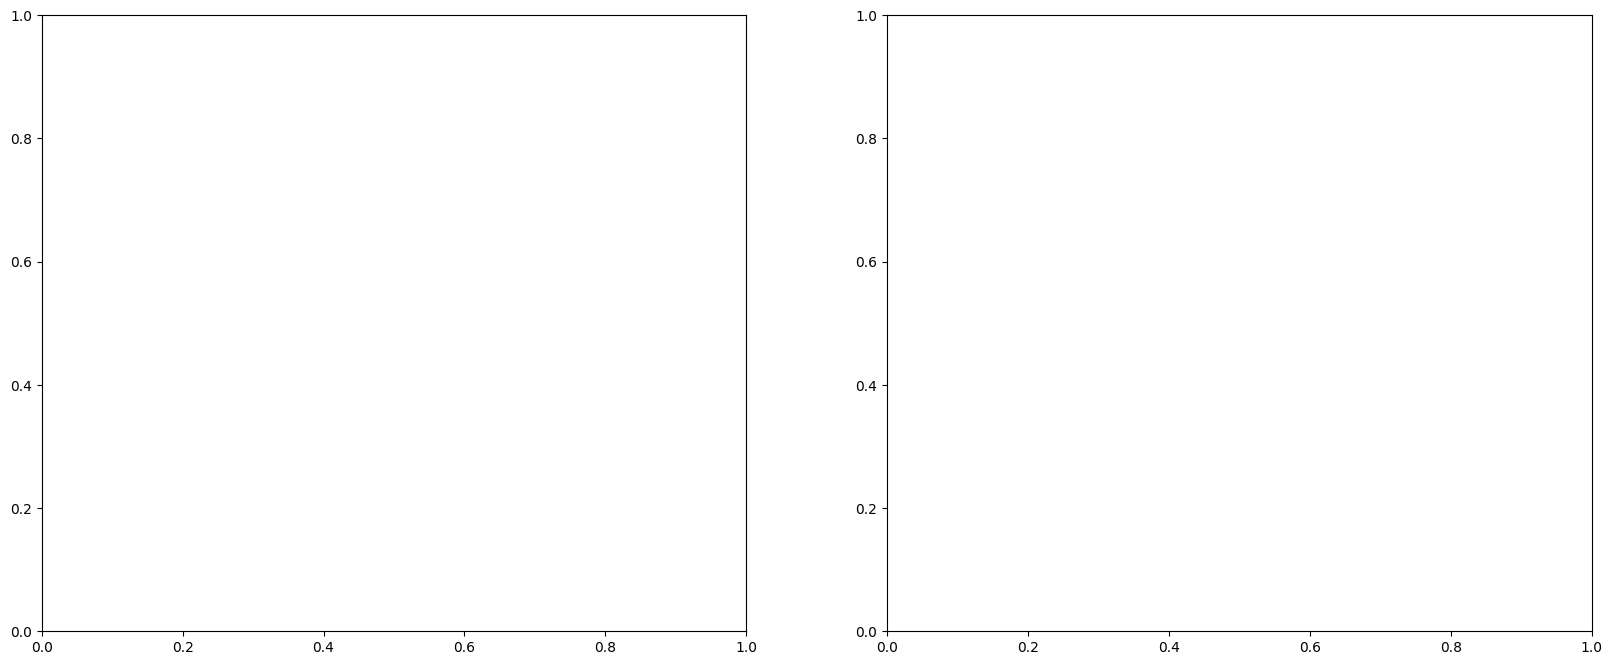

In [ ]:
# BLOCO 2 OK
# cria figura com 2 subplots/subgrafico lado a lado
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

# lista de variáveis e títulos que vão ser plotados lado a a lado
variaveis = ["meses_de_relacionamento", "qtd_produtos"]
titulos = ["Uso percentual x Meses de relacionameno", "Uso percentual x Quantidade de produtos"]

desloc_horiz = -0.2  # deslocamento horizontal das legendas min, max, quartis, etc.

for i, var in enumerate(variaveis):
    # boxplot principal
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, color="lavender", ax=eixo[i])
    eixo[i].set_title(titulos[i]) # título de cada subgráfico
    eixo[i].tick_params(axis="x", rotation=45) # rotação das legendas/rótulos do eixo
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7) # opcional, é só pra colocar uma linha de grade de fundo

    # pega os rótulos do eixo x (pra calcular os valores dos quartis, min, max, etc. mais adiante; aqui só faz a listagem)
    ordem_plot = [cat.get_text() for cat in eixo[i].get_xticklabels()]

    for j, cat in enumerate(ordem_plot):
        # tenta converter o rótulo para número; se não conseguir, mantém como está
        try:
            cat_val = float(cat)
        except ValueError:
            cat_val = cat

        # seleciona os valores correspondentes no df pra calcular os valores dos quartis, min, max, etc.
        valores = df_ajustado_final[df_ajustado_final[var] == cat_val]["uso_percentual_limite"].dropna()

        if len(valores) > 0: #sobre os valores listados, usa essas funções do pandas e começa a fazer os cálculos dos quantiles, min, max, pra usar nas legendinhas sobre os boxplots
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)
            iqr = q3 - q1
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()
            outlier_maximo = valores.max()

            posicao_x = j + desloc_horiz # só pra indicar onde essas legendinhas vão ficar; a que distancia horizontal; eu não quis deixar centralizado

            # adiciona as legendinhas com os valores sobre o gráfico
            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=12, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=12, color="black")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=12, color="blue")

            if outlier_maximo > whisker_superior: # só verifica se existe um ponto acima do limite normal (wisker_superior); o outlier_maximo é pra ser o maior valor real da amostra
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=12, color="red") # aqui sõa as orientações para escrever esse valorzinho sobre o gráfico

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------
# BIBLIOTECAS
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------------------------------------------
# 1) CRIAR FAIXAS AUTOMÁTICAS PARA "MESES DE RELACIONAMENTO"
# ---------------------------------------------------------------
# O objetivo é transformar os meses de relacionamento em grupos/categorias,
# para o gráfico mostrar essas faixas (ex: "0–6", "7–12", etc.) no eixo X.

# pd.qcut divide a coluna em partes de tamanhos iguais (por quantis).
faixas_meses = pd.qcut(
    df_ajustado_final["meses_de_relacionamento"],
    q=6,              # número de faixas desejadas
    duplicates="drop" # evita erro se houver faixas repetidas
)

# Criamos legendas com valores inteiros (sem casas decimais) para deixar mais legível.
faixas_formatadas = []
for intervalo in faixas_meses.cat.categories:
    minimo = int(np.floor(intervalo.left))   # limite inferior (arredondado para baixo)
    maximo = int(np.ceil(intervalo.right))   # limite superior (arredondado para cima)
    faixas_formatadas.append(f"{minimo}-{maximo}")  # ex: "0-6", "7-12", etc.

# Atualizamos as categorias com essas legendas limpas
faixas_meses = faixas_meses.cat.rename_categories(faixas_formatadas)

# E adicionamos essa nova coluna ao dataframe
df_ajustado_final["faixa_meses_relacionamento"] = faixas_meses


# ---------------------------------------------------------------
# 2) CONFIGURAR A FIGURA COM DOIS SUBGRÁFICOS LADO A LADO
# ---------------------------------------------------------------
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))  # cria 2 subgráficos na mesma linha

# As duas variáveis que queremos comparar com o "uso_percentual_limite"
variaveis = ["faixa_meses_relacionamento", "qtd_produtos"]

# Títulos correspondentes de cada gráfico
titulos = ["Uso percentual x Meses de Relacionamento", "Uso percentual x Nº de Produtos"]

# Ajuste para deslocar um pouquinho as legendinhas horizontalmente
desloc_horiz = -0.2


# ---------------------------------------------------------------
# 3) LOOP PRINCIPAL — PERCORRE CADA VARIÁVEL E GERA O GRÁFICO
# ---------------------------------------------------------------
for i, var in enumerate(variaveis):

    # Cria o boxplot principal (um para cada variável)
    sns.boxplot(
        x=var,
        y="uso_percentual_limite",
        data=df_ajustado_final,
        color="lavender",
        ax=eixo[i]
    )

    # Título, rotação dos rótulos e grade de fundo
    eixo[i].set_title(titulos[i])
    eixo[i].tick_params(axis="x", rotation=45)
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7)

    # Captura os nomes/rótulos de cada categoria no eixo X
    rotulos_x = [cat.get_text() for cat in eixo[i].get_xticklabels()]

    # -----------------------------------------------------------
    # LOOP INTERNO — PERCORRE CADA CATEGORIA DENTRO DO BOXPLOT
    # -----------------------------------------------------------
    for j, cat in enumerate(rotulos_x):

        # Tenta converter o rótulo para número (caso da "qtd_produtos")
        # Se não conseguir (caso da faixa), mantém como texto
        try:
            cat_val = float(cat)
        except ValueError:
            cat_val = cat

        # Filtra os dados que pertencem àquela categoria específica
        if var == "faixa_meses_relacionamento":
            filtro = df_ajustado_final[var].astype(str) == str(cat_val)
        else:
            filtro = df_ajustado_final[var] == cat_val

        # Pega apenas os valores válidos (não nulos)
        valores = df_ajustado_final.loc[filtro, "uso_percentual_limite"].dropna()

        # Se houver dados para essa categoria...
        if len(valores) > 0:

            # Calcula os quartis e limites superiores
            q1 = valores.quantile(0.25)  # primeiro quartil (25%)
            q2 = valores.quantile(0.5)   # mediana (50%)
            q3 = valores.quantile(0.75)  # terceiro quartil (75%)
            iqr = q3 - q1                 # intervalo interquartil
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()  # limite superior normal
            outlier_maximo = valores.max()  # valor máximo real (pode ser um outlier)

            # Define onde o texto será desenhado (no eixo X)
            posicao_x = j + desloc_horiz

            # Adiciona legendinhas com os valores diretamente no gráfico
            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}",
                         ha='center', va='bottom', fontsize=12, color="blue")   # mínimo
            eixo[i].text(posicao_x, q1, f"{q1:.1f}",
                         ha='center', va='bottom', fontsize=12, color="green")  # Q1
            eixo[i].text(posicao_x, q2, f"{q2:.1f}",
                         ha='center', va='bottom', fontsize=12, color="black")  # Mediana
            eixo[i].text(posicao_x, q3, f"{q3:.1f}",
                         ha='center', va='bottom', fontsize=12, color="green")  # Q3
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}",
                         ha='center', va='bottom', fontsize=12, color="blue")   # Whisker superior

            # Se houver um valor acima do whisker (outlier), destacamos em vermelho
            if outlier_maximo > whisker_superior:
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}",
                             ha='center', va='bottom', fontsize=12, color="red")

# ---------------------------------------------------------------
# 4) AJUSTE FINAL DO LAYOUT E EXIBIÇÃO
# ---------------------------------------------------------------
plt.tight_layout()  # ajusta espaçamento entre os subgráficos
plt.show()          # exibe a figura


NameError: name 'df_ajustado_final' is not defined

🔸Sobre os meses de relacionamento:
*   Observa-se uma tendência de leve queda no uso percentual do limite conforme aumenta o tempo de relacionamento do cliente com o banco.
*   Clientes com menos tempo de relacionamento (12–28 meses) tendem a usar mais intensamente o limite, com mediana próxima de 78,5%, enquanto aqueles com relacionamentos mais longos (44–56 meses) apresentam mediana mais baixa, cerca de 64,4%.
*   A dispersão (altura das caixas) diminui ligeiramente nas faixas mais longas, sugerindo comportamento mais homogêneo entre clientes antigos.
*   A presença de outliers altos (acima de 400–500%) em todas as faixas mostra que há casos extremos de uso muito elevado, independentemente do tempo de relacionamento.

🔸Sobre as quantidades de produtos:
*   Nota-se uma queda significativa no uso percentual à medida que o cliente possui mais produtos com o banco. A partir de 3 produtos, o uso percentual cai para patamares próximos de 65–70%, e mantém-se relativamente estável até 6 produtos.
*   Clientes com 1 ou 2 produtos têm medianas mais altas (111,9% e 101,8%, respectivamente), indicando que usam o limite além da capacidade normal (uso acima de 100%).
*   A variabilidade do uso (diferença entre quartis) é maior nos clientes com poucos produtos, sugerindo heterogeneidade comportamental nesse grupo.
*   Assim como no gráfico anterior, há outliers em todos os grupos, mas o volume tende a diminuir conforme aumenta o número de produtos.

Os resultados sobre os meses de relacionamento podem indicar que clientes mais antigos se tornam mais estáveis financeiramente, ou que o banco ajusta seus limites de crédito conforme o tempo, reduzindo o percentual de uso. Também é possível que novos clientes ainda estejam explorando o crédito para construção de histórico, o que eleva o uso proporcional do limite.

Os resultados sobre a quantidade de produtos sugere que clientes com relacionamento mais diversificado (maior número de produtos) têm comportamento financeiro mais equilibrado e dependem menos do crédito rotativo. Pode refletir também maior confiança e poder aquisitivo, ou um maior acesso a outras linhas de crédito, diluindo o uso concentrado no cartão. Já quem tem poucos produtos tende a usar o cartão como principal fonte de crédito, o que explica o uso elevado e até acima do limite.

Agora vamos usar o `relplot()` para avaliar a relação entre as duas variáveis.

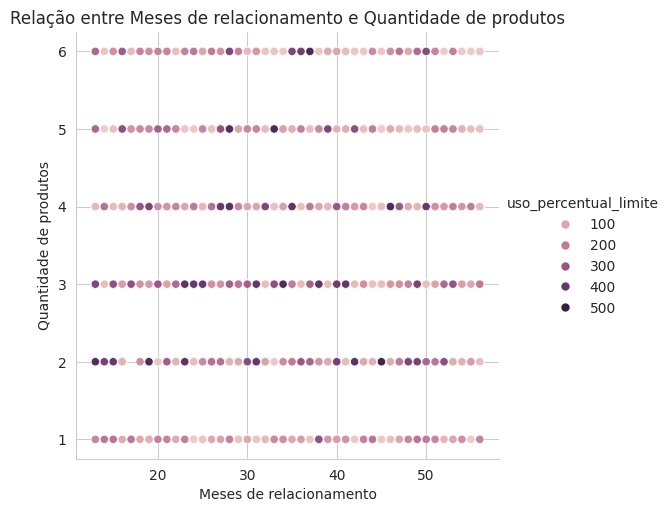

In [ ]:
f = sns.relplot(x='meses_de_relacionamento', y='qtd_produtos', data=df_ajustado_final, hue='uso_percentual_limite')
_ = f.set(title='Relação entre Meses de relacionamento e Quantidade de produtos', xlabel='Meses de relacionamento', ylabel='Quantidade de produtos')

Os pontos estão espalhados por toda a faixa de meses, o que sugere que o número de produtos não depende claramento do tempo de relacionamento. Note que há clientes com 1 produto tanto quanto com 10 meses quanto com 50 meses de relacionamento, por exemplo. O mesmo vale para quem tem 2, 3 ou mais produtos.

Quanto aos tons das cores, elas estão espalhadas de forma aleatória em todas as faixas de prodtos e meses, de modo que não há uma concentração visível de cores mais escuras (maior uso percentual do limite) em terminadas regiões nem de mais claras (menor uso). Assim, não vemos nenhum tipo de padrão como, por exemplo, quanto mais (ou menos) tempo de relacionamento, maior (ou menor) o uso limite.

Vou plotar o mapa de calor das correlações de Pearson e Spearman para avaliar por outra caminho se essa não relação de fato se sustenta.

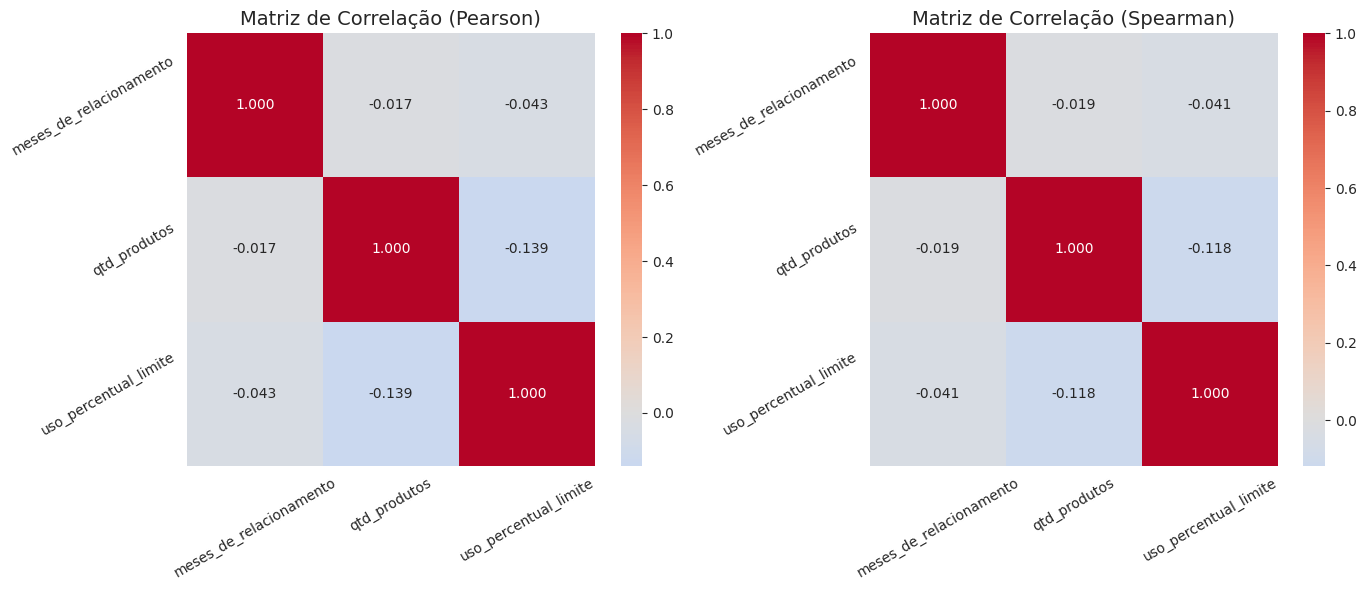

In [ ]:
subset = df_ajustado_final[["meses_de_relacionamento", "qtd_produtos", "uso_percentual_limite"]]

# correlações
corr_pearson = subset.corr(method="pearson")
corr_spearman = subset.corr(method="spearman")

figura, eixos = plt.subplots(1, 2, figsize=(14, 6))

corrs = [corr_pearson, corr_spearman] #lista das correlações para puxar no grafico
titulos = ["Matriz de Correlação (Pearson)", "Matriz de Correlação (Spearman)"]

# desenhando as duas matrizes
for i, (corr, titulo) in enumerate(zip(corrs, titulos)):
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f", ax=eixos[i])
    eixos[i].set_title(titulo, fontsize=14)

    # rotação das legendas dos eixos
    eixos[i].tick_params(axis='x', rotation=30)
    eixos[i].tick_params(axis='y', rotation=30)

plt.tight_layout()
plt.show()


Note que:

*   Meses de relacionamento x Quantidade de produtos = -0.017
> Corelação praticamente nula. O tempo de relacionamento com o banco não influencia a quantidade de produtos.
*   Meses de relacionamento x Uso percentual do limite = -0.043
> Correlação negativa muito fraca. Os clientes mais antigos usam levemente menos o limite do cartão, mas o efeito é irrelevante.
*   Quantidade de produtos x Uso percentual do limite = -0.139
> Correlação negativa fraca: quanto mais produtos o cliente tem, tende a usar um pouco menos o limite.


Portanto, o uso percentual do limite não varia sistematicamente com o tempo de relacionamento nem com o número de produtos.

#### **Iterações 12 meses e Meses inativo**

Agora vamos avaliar essas duas métricas: ``iteracoes_12m`` é a quantidade de iteracoes com o cliente no último ano e ``meses_inativo_12m`` é a quantidade de meses que o cliente ficou inativo no último ano. Abaixo segue o describe().

In [ ]:
df_ajustado_final[['iteracoes_12m', 'meses_inativo_12m']].describe()

,iteracoes_12m,meses_inativo_12m
count,7081.000000,7081.000000
mean,2.454456,2.342607
std,1.104917,0.995104
min,0.000000,0.000000
25%,2.000000,2.000000
50%,2.000000,2.000000
75%,3.000000,3.000000
max,6.000000,6.000000


Abaixo seguem os gráficos. Como essas variáveis assumem valores discretos, basta usar o ``countplot``.

/tmp/ipython-input-3274059490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')
/tmp/ipython-input-3274059490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')


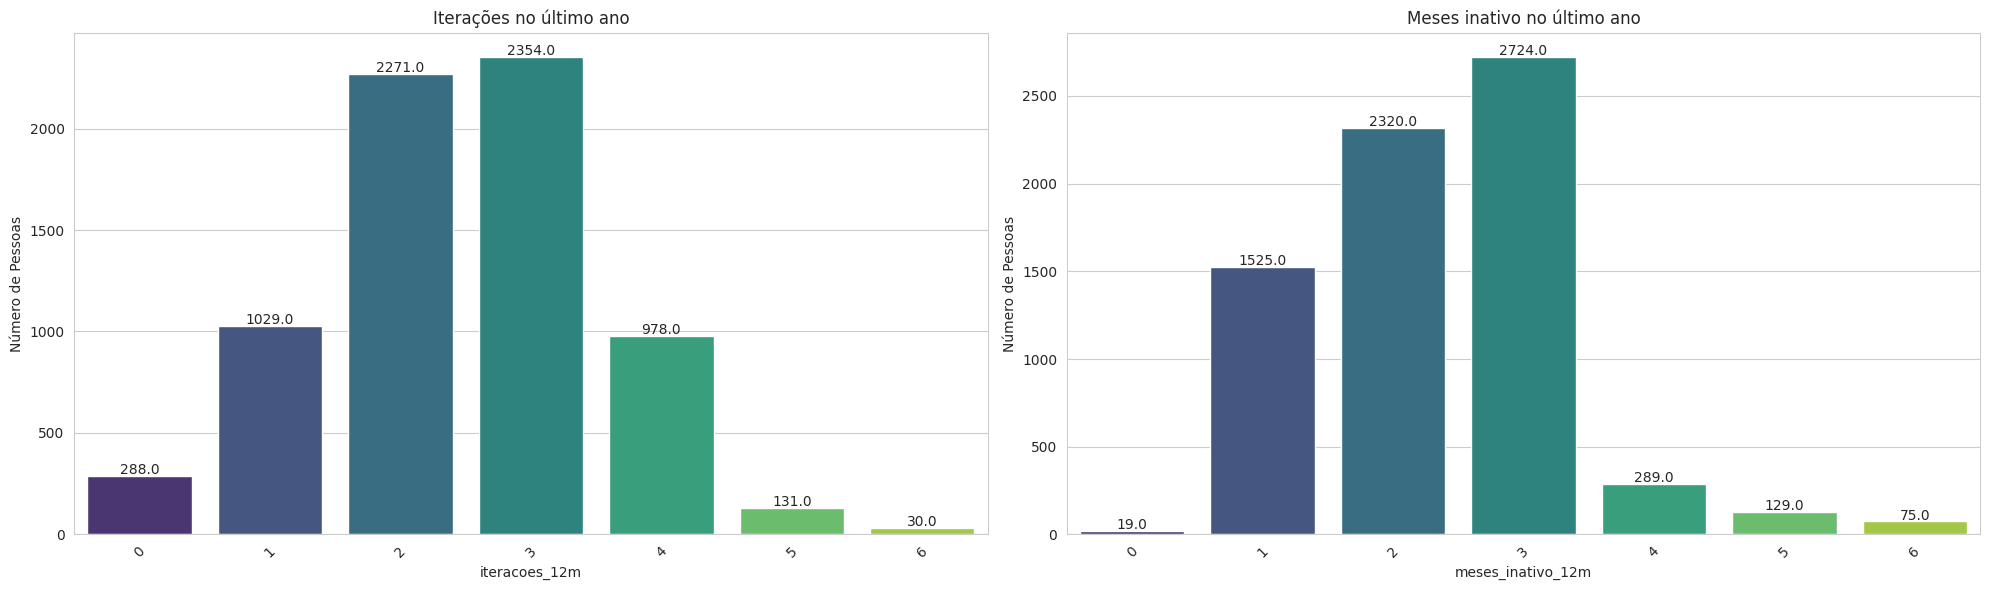

In [ ]:
figura, eixo = plt.subplots(1, 2, figsize=(20, 6))

variaveis = ["iteracoes_12m", "meses_inativo_12m"]
titulos = ["Iterações no último ano", "Meses inativo no último ano"]


for i, var in enumerate(variaveis):
    sns.countplot(x=var, data=df_ajustado_final, ax=eixo[i], palette='viridis')

    eixo[i].set_title(titulos[i])
    eixo[i].set_ylabel("Número de Pessoas")
    eixo[i].tick_params(axis="x", rotation=45)

    # vai adiciona as contagens/legendinhas de dados em cima de cada barra
    for p in eixo[i].patches:
        height = p.get_height()
        eixo[i].text(p.get_x() + p.get_width()/2., height + 10, height, ha="center")

plt.tight_layout()
plt.show()

Podemos notar que:

🔸Sobre as iterações no último ano:
*   A
*   Is

🔸Sobre os usuários inativos no último ano:
*   A
*   Is

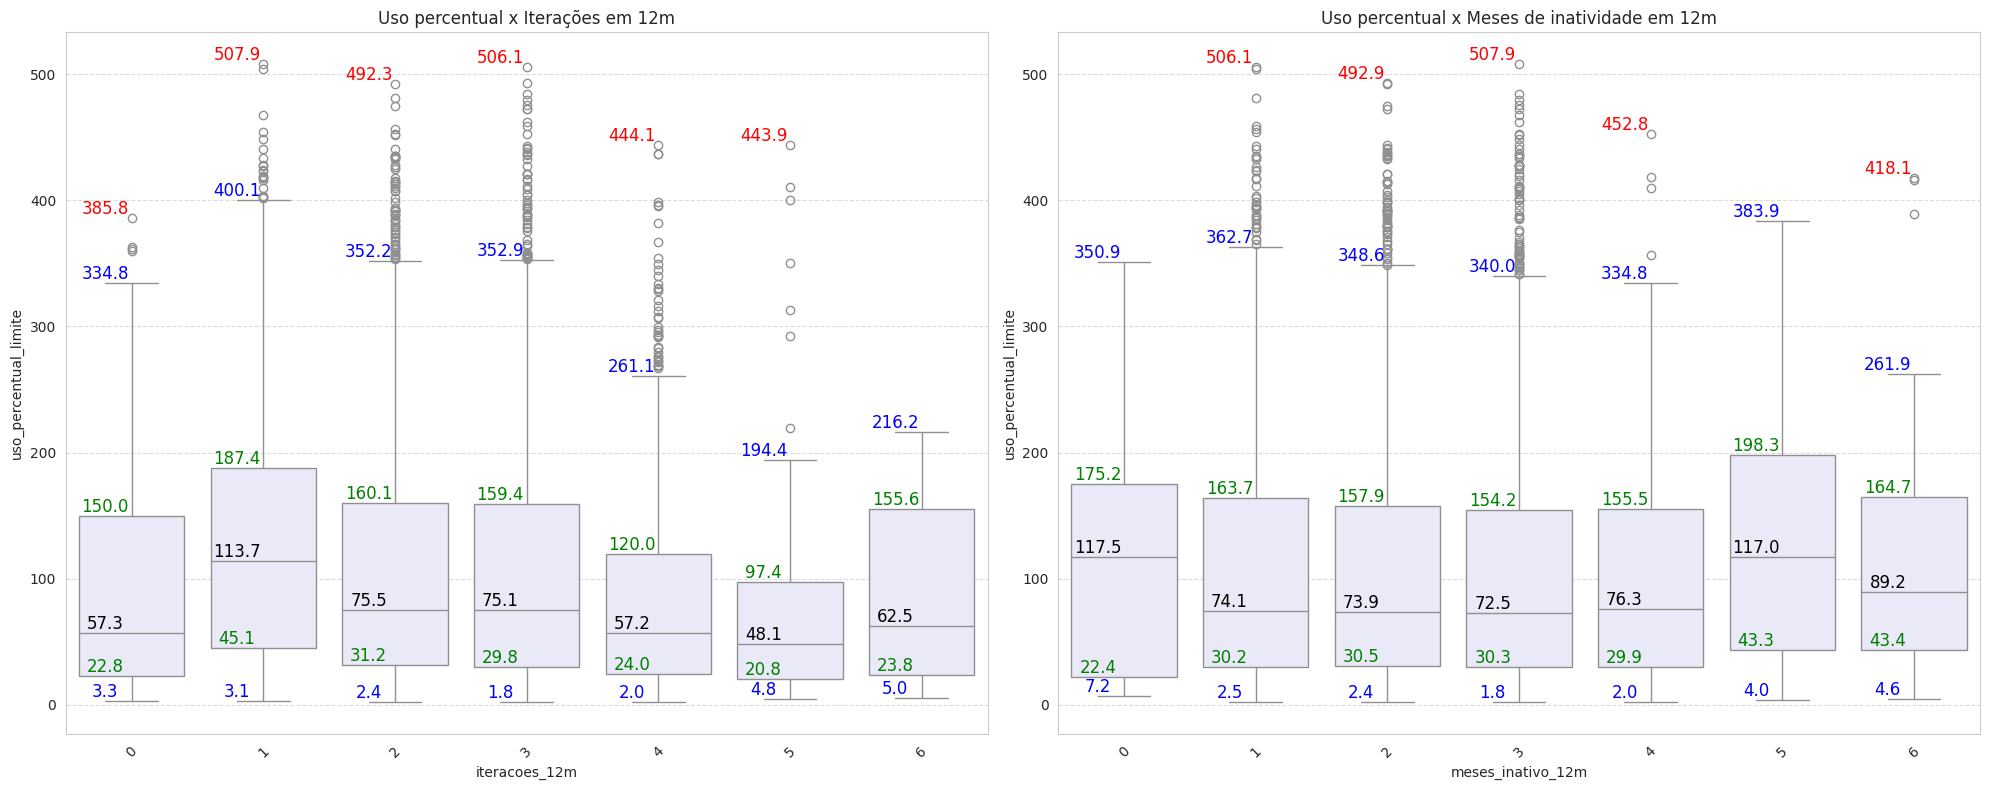

In [ ]:
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

variaveis = ["iteracoes_12m", "meses_inativo_12m"]
titulos = ["Uso percentual x Iterações em 12m", "Uso percentual x Meses de inatividade em 12m"]

desloc_horiz = -0.2  # controla deslocamento horizontal das legendas

for i, var in enumerate(variaveis):
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, color="lavender", ax=eixo[i])
    eixo[i].set_title(titulos[i])
    eixo[i].tick_params(axis="x", rotation=45)
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7)

    ordem_plot = [cat.get_text() for cat in eixo[i].get_xticklabels()]

    for j, cat in enumerate(ordem_plot):
        #conversão do rótulo para o tipo correto da coluna
        try:
            cat_val = df_ajustado_final[var].dtype.type(cat)
        except:
            cat_val = cat

        valores = df_ajustado_final[df_ajustado_final[var] == cat_val]["uso_percentual_limite"].dropna()

        if len(valores) > 0:
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)

            outlier_maximo = valores.max()
            iqr = q3 - q1
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max()

            posicao_x = j + desloc_horiz

            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=12, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=12, color="black")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=12, color="blue")

            if outlier_maximo > whisker_superior:
                eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=12, color="red")

plt.tight_layout()
plt.show()


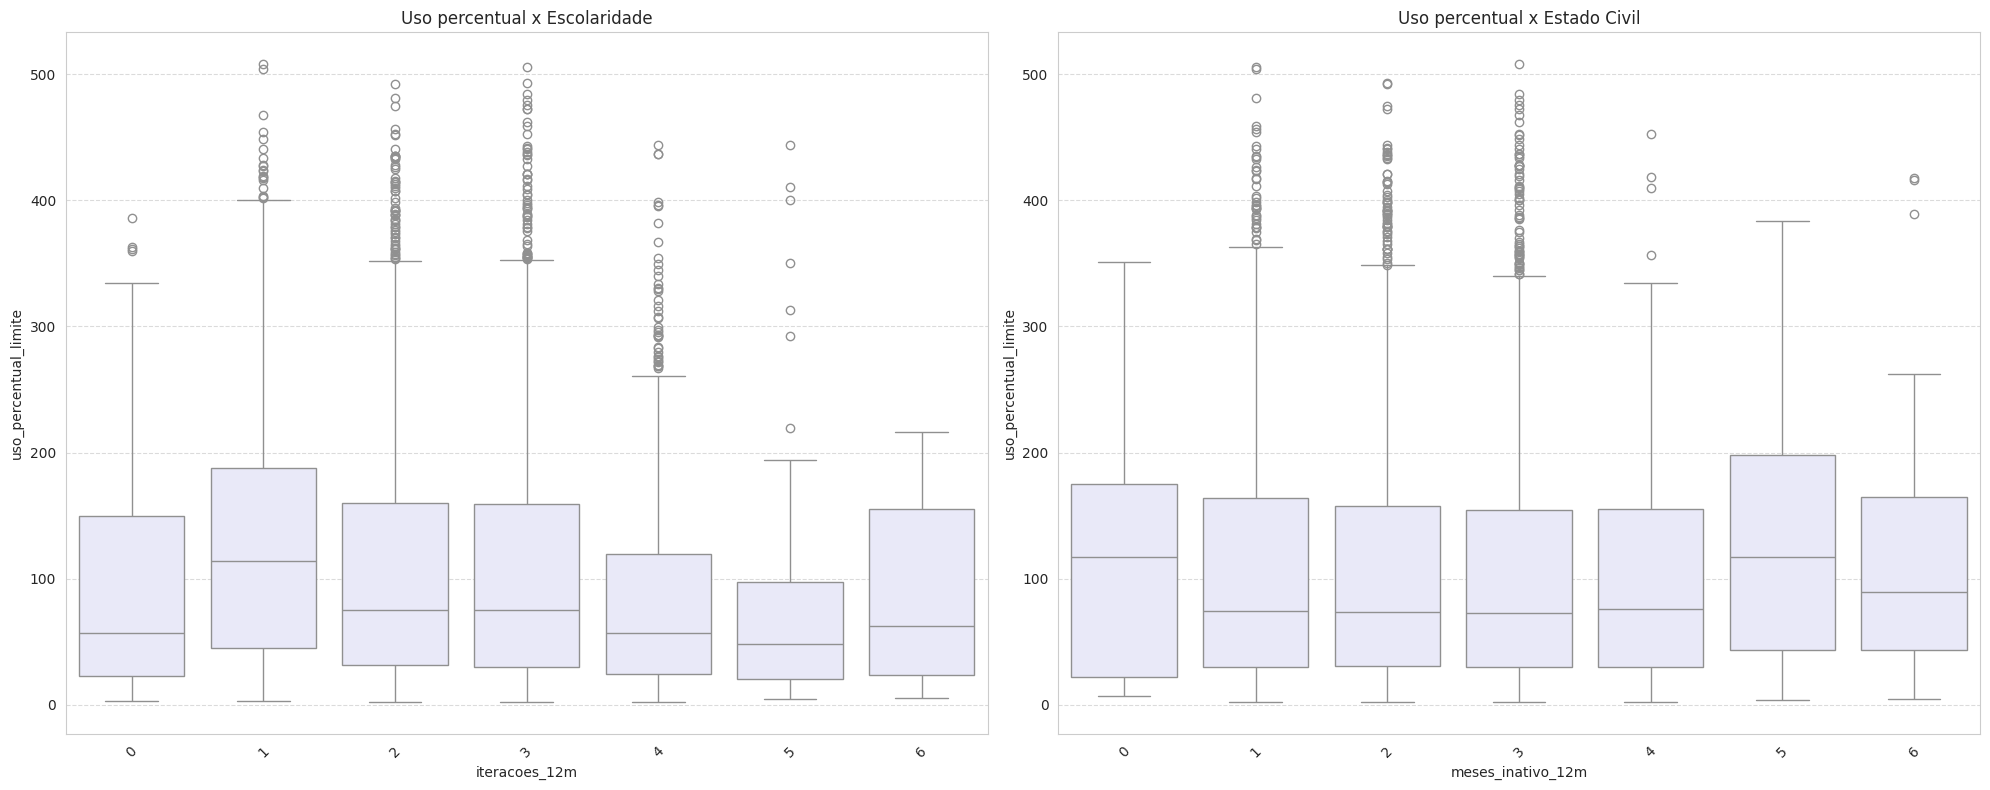

In [ ]:
figura, eixo = plt.subplots(1, 2, figsize=(20, 8))

variaveis = ["iteracoes_12m", "meses_inativo_12m"]
titulos = ["Uso percentual x Escolaridade", "Uso percentual x Estado Civil"]
# variáveis e titulos sao listas que guardam os nomes das colunas que serão usadas para os boxplots e os titulos correspondentes a cada subgrafico

desloc_horiz = -0.2 # variável que vai regular o deslocamento horizontal

for i, var in enumerate(variaveis): # esse for indica um loop que vai passar por cada categioria ( escolaridade, ...); i é usada para selecionar o subgrafico correto em eixo[i]
    sns.boxplot(x=var, y="uso_percentual_limite", data=df_ajustado_final, color="lavender", ax=eixo[i]) #usa a biblioteca do seaborn para plotar o gráfico; tbm coloquei uma cor diferente
    eixo[i].set_title(titulos[i]) # define o titulo do subgrafico
    eixo[i].tick_params(axis="x", rotation=45) # gira em 45º os rotulos/legendas do eixo x, pra evitar sobreposicao
    eixo[i].grid(axis='y', linestyle='--', alpha=0.7) #adiciona linhas de grade horizontais

    ordem_plot = [cat.get_text() for cat in eixo[i].get_xticklabels()]
    # vai garantir que as legendas de dados, após calculadas no bloco abaixo, vão ser inseridas na mesma ordem que a daas categorais plotadas no eixo x pelo seaborn

    for j, cat in enumerate(ordem_plot): #esse loop percorre cada categoria na ordem correta
        valores = df_ajustado_final[df_ajustado_final[var] == cat]["uso_percentual_limite"].dropna() #filtra o df para obter apensas os dados da categoria de interesse por loop

        if len(valores) > 0: # calcula os min, max, q1, etc; a condição >- garante que o calculo é feito apenas se houver dados nessa categoria
            q1 = valores.quantile(0.25)
            q2 = valores.quantile(0.5)
            q3 = valores.quantile(0.75)

            outlier_maximo = valores.max()
            iqr = q3 - q1 #intervalo interquartil
            whisker_superior = valores[valores <= (q3 + 1.5 * iqr)].max() #limite do boxplot antes dos outiliers
            # o trecho valores <= (q3 + 1.5 * iqr) é a formula para o limite superior do boxplot; qlq valor acima desse limite é considerado um outlier
            #o trecho valores[valores <= (q3 + 1.5 * iqr)] seleciona apenas os valores menores ou iguais ao limite superior; remove os outliers


            # desloca um pouco horizontalmente os valores da legenda de dados
            posicao_x = j + desloc_horiz

            #  adiciona ao gráfico as legendas de dados
            eixo[i].text(posicao_x, valores.min(), f"{valores.min():.1f}", ha='center', va='bottom', fontsize=12, color="blue")
            eixo[i].text(posicao_x, q1, f"{q1:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, q2, f"{q2:.1f}", ha='center', va='bottom', fontsize=12, color="black")
            eixo[i].text(posicao_x, q3, f"{q3:.1f}", ha='center', va='bottom', fontsize=12, color="green")
            eixo[i].text(posicao_x, whisker_superior, f"{whisker_superior:.1f}", ha='center', va='bottom', fontsize=12, color="blue")

            if outlier_maximo > whisker_superior:# quando ocorre o maior outlier, ele recebe com vermelha, etc...
                 eixo[i].text(posicao_x, outlier_maximo, f"{outlier_maximo:.1f}", ha='center', va='bottom', fontsize=12, color="red")

plt.tight_layout()
plt.show()

/tmp/ipython-input-2514895351.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ajustado_final, x='faixa_etaria', y='uso_percentual_limite', estimator='mean', ci=None, ax=axes[2], palette='viridis')
/tmp/ipython-input-2514895351.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ajustado_final, x='faixa_etaria', y='uso_percentual_limite', estimator='mean', ci=None, ax=axes[2], palette='viridis')


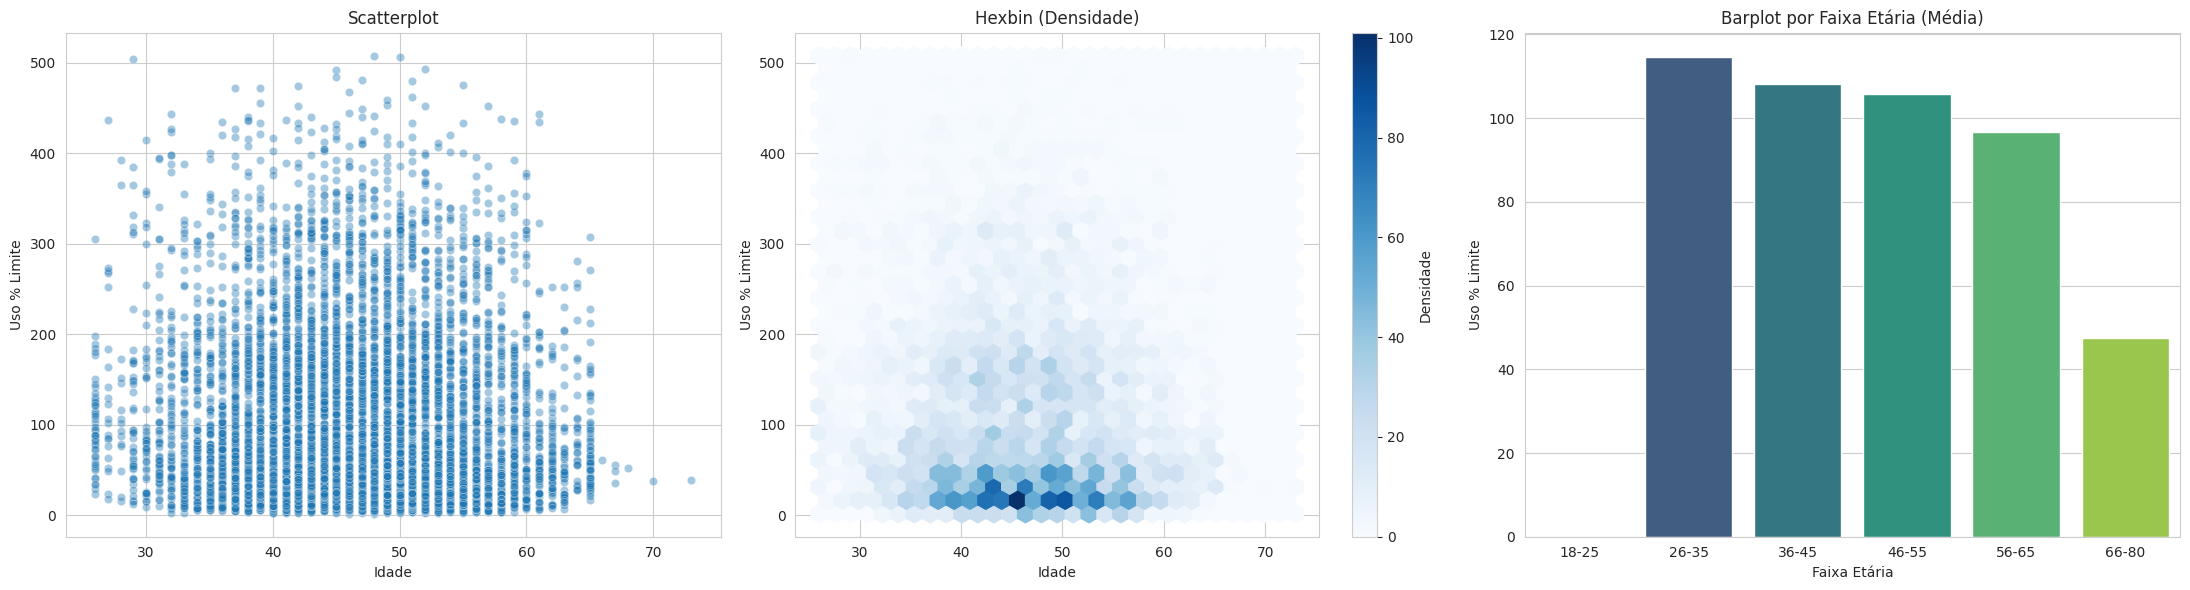

In [ ]:
# Criar faixas etárias para o barplot
bins = [18, 25, 35, 45, 55, 65, 80]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-80']
df_ajustado_final['faixa_etaria'] = pd.cut(df_ajustado_final['idade'], bins=bins, labels=labels)

# Criar a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1️⃣ Scatterplot (sem linha de regressão)
sns.scatterplot(data=df_ajustado_final, x='idade', y='uso_percentual_limite', alpha=0.4, ax=axes[0])
axes[0].set_title('Scatterplot')
axes[0].set_ylabel('Uso % Limite')
axes[0].set_xlabel('Idade')

# 2️⃣ Hexbin plot (densidade)
hb = axes[1].hexbin(df_ajustado_final['idade'], df_ajustado_final['uso_percentual_limite'], gridsize=30, cmap='Blues')
axes[1].set_title('Hexbin (Densidade)')
axes[1].set_ylabel('Uso % Limite')
axes[1].set_xlabel('Idade')
fig.colorbar(hb, ax=axes[1], label='Densidade')

# 3️⃣ Barplot por faixa etária (média)
sns.barplot(data=df_ajustado_final, x='faixa_etaria', y='uso_percentual_limite', estimator='mean', ci=None, ax=axes[2], palette='viridis')
axes[2].set_title('Barplot por Faixa Etária (Média)')
axes[2].set_ylabel('Uso % Limite')
axes[2].set_xlabel('Faixa Etária')

plt.tight_layout()
plt.show()



|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||


|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||

|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||


# Curiosidades e outros aprendizados no processo do estudo

## 🚨Diferença entre `df.dropna` e `df.dropna(inplace=True)`


Vimos que para remover as linhas faltantes utilizamos o



```
df.dropna(inplace=True) ## remove NaNs direto no df; df agora não tem mais linhas com NaN
```


Porém o professor também comenta a possibilidade de usar a forma:

```
df = df.dropna() ## # cria um novo dataframe sem NaNs e salva na variável df; df agora é o novo dataframe sem NaNs
```
mas que dessa forma estaríamos reatribuindo o novo df para df.

Em consulta ao ChatGPT, vi que esses 2 formatos têm as seguintes diferenças:


*   `df.dropna(inplace=True)`

1.   Altera o próprio dataframe df diretamente, sem criar uma cópia.
2.   Ou seja, os valores ausentes (NaN) são removidos no próprio objeto df, e ele é modificado em memória.
3.   Não retorna nada (retorna None), pois a operação é feita "in place" (no lugar).

*   `df = df.dropna()`

1.   Cria um novo dataframe, que é o resultado de remover as linhas com NaN, e atribui esse novo dataframe à variável df.
2.   O dataframe antigo (antes de remover os NaNs) é sobrescrito por esse novo, mas o processo ocorre via atribuição, não via alteração direta.

#### Qual usar?


🟩 Se você quer alterar o dataframe diretamente, sem precisar criar outro, use inplace=True.

🟦 Se quer um código mais claro, seguro, e evitar efeitos colaterais não intencionais, prefira df = df.dropna().

🔧 A própria documentação do pandas recomenda evitar inplace=True, pois em muitas situações a atribuição direta (df = df.dropna()) é mais clara, previsível e até mais eficiente internamente.


| Forma                     | Efeito no dataframe | Retorna valor? | Estilo                  |
| ------------------------- | ------------------- | -------------- | ----------------------- |
| `df.dropna(inplace=True)` | Altera diretamente  | ❌ None         | Efeito colateral direto |
| `df = df.dropna()`        | Cria uma nova cópia | ✅ DataFrame    | Mais explícito e seguro |


## 🚨Usos do paradigma Procedural e POO + Programação Funcional

Pedi para o Chat GPT me ajudar a reescrever oeu código para calcular a porcentagem de escolaridade, estado_civil e salario_anual antes e depois da limpeza dos dados (em que usei o paradigma procedural) usando POO e Programação Funcional (com map, lambda, etc).

Ele retornou o código abaixo:

In [ ]:
import pandas as pd

class ProporcaoCategorias:
    def __init__(self, df_original, df_limpo):
        self.df_original = df_original
        self.df_limpo = df_limpo
        self.qtd_total_antes = df_original.shape[0]
        self.qtd_total_depois = df_limpo.shape[0]

    def calcular_proporcao(self, coluna):
        print(f'\nProporção ANTES e DEPOIS da limpeza de dados para a coluna "{coluna}":\n')

        # Lista de tipos únicos (incluindo NaN)
        tipos_unicos = self.df_original[coluna].unique()

        # Função auxiliar para calcular proporção
        def calcular(tipo):
            if pd.isna(tipo):
                qtd_antes = self.df_original[coluna].isna().sum()
                qtd_depois = self.df_limpo[coluna].isna().sum()
                tipo_str = 'NaN'
            else:
                qtd_antes = (self.df_original[coluna] == tipo).sum()
                qtd_depois = (self.df_limpo[coluna] == tipo).sum()
                tipo_str = tipo

            # Calcula porcentagens
            perc_antes = round(qtd_antes / self.qtd_total_antes * 100, 2)
            perc_depois = round(qtd_depois / self.qtd_total_depois * 100, 2)

            return f'- {tipo_str}: antes = {perc_antes}% | depois = {perc_depois}%'

        # Usando map para aplicar a função em todos os tipos
        resultados = map(calcular, tipos_unicos)

        # Exibe os resultados
        print('\n'.join(resultados))

    def analisar_colunas(self, colunas):
        list(map(self.calcular_proporcao, colunas))

# --- Exemplo de uso:
# Criando o objeto da classe e rodando a análise
proporcao = ProporcaoCategorias(df_original=df, df_limpo=df_ajustado)
proporcao.analisar_colunas(['escolaridade', 'estado_civil', 'salario_anual'])



Proporção ANTES e DEPOIS da limpeza de dados para a coluna "escolaridade":

- ensino medio: antes = 19.88% | depois = 23.34%
- mestrado: antes = 30.89% | depois = 36.59%
- sem educacao formal: antes = 14.68% | depois = 17.0%
- NaN: antes = 15.0% | depois = 0.0%
- graduacao: antes = 10.0% | depois = 11.92%
- doutorado: antes = 9.55% | depois = 11.14%

Proporção ANTES e DEPOIS da limpeza de dados para a coluna "estado_civil":

- casado: antes = 46.28% | depois = 50.33%
- solteiro: antes = 38.94% | depois = 41.63%
- NaN: antes = 7.4% | depois = 0.0%
- divorciado: antes = 7.39% | depois = 8.04%

Proporção ANTES e DEPOIS da limpeza de dados para a coluna "salario_anual":

- $60K - $80K: antes = 13.84% | depois = 15.58%
- menos que $40K: antes = 35.16% | depois = 39.43%
- $80K - $120K: antes = 15.16% | depois = 16.98%
- $40K - $60K: antes = 17.68% | depois = 19.94%
- $120K +: antes = 7.18% | depois = 8.08%
- NaN: antes = 10.98% | depois = 0.0%


Achei que ficou muito extenso, embora bem intuitivo na parte da função map.

Pedi para o Chat indicar quando pode ser mais recomendado usar um ou outro (porque é importante ter outras visões, além da do professor). O Chat indicou as seguintes:

✅ Quando Procedural (seu código) é Melhor
✔️ Projetos pequenos e médios, focados em análise exploratória rápida, como é o seu caso;

✔️ Leitura e manutenção simples;

✔️ Fluxo linear (leitura, tratamento, análise);

✔️ Equipes ou projetos onde clareza e velocidade de desenvolvimento são prioridade.

Seu código está super adequado para o contexto do Google Colab, onde:

Você quer testar hipóteses rápidas;

O foco está nos dados, não na arquitetura do código.

✅ Quando POO ou Funcional é Melhor
🔶 Em projetos grandes, que precisam escalar, reaproveitar e organizar o código;

🔶 Se você quiser transformar em pacotes reutilizáveis, dashboards, ou APIs;

🔶 Quando há várias operações semelhantes em diferentes DataFrames;

🔶 Quando precisa reduzir repetições (DRY - Don't Repeat Yourself).

## 3 formas diferentes de su usar a função range()

A função range pode ser usada de 3 formas:



1.   *range(stop)*
2.   *range(start, stop)*
3.   *range(start, stop, step)*



### *range(stop)*

Essa forma gera uma sequência de números de 0 até o valor indicado no stop, mas não incluindo.

Por padrão (default), o incremento é de 1 em 1.

In [ ]:
for i in range(5):
  print(i)

0
1
2
3
4


### *range(start, stop)*

Essa forma gera uma sequência de números começando em *start*, que é incluído,  até o valor indicado no stop, mas não incluindo.

Por padrão (default), o incremento é de 1 em 1.

In [ ]:
for i in range(2, 7):
  print(i)

2
3
4
5
6


### *range(start, stop, step)*

Essa forma gera uma sequência de números começando em *start*, que é incluído,  até o valor indicado no *stop*, mas não incluindo.

Aqui o incremento é indicado, podendo ser positivo ou negativo.

In [ ]:
print('Exemplo com incremento positivo:\n')
for i in range(1, 10, 2):
  print(i)

print('\n')
print('Exemplo com incremento negativo:\n')

for i in range(10, 0, -1):
  print(i)

Exemplo com incremento positivo:

1
3
5
7
9


Exemplo com incremento negativo:

10
9
8
7
6
5
4
3
2
1


## Sobre `relplot()`

O sns.relplot é uma figure-level function, ou seja, funciona como um gerenciador que chama outras funções internas (scatterplot ou lineplot) e organiza os gráficos em um grid se solicitado (col=, row=).


🔹 O que faz:

>Cria gráficos de relações entre variáveis (daí o nome relplot).
>
>É uma função de alto nível que, por padrão, chama:
>
>>scatterplot → se não houver agregação/ordem.
>
>>lineplot → se você especificar kind="line".

🔹Características:
>
>Sempre exige duas variáveis numéricas (x e y), porque seu foco é mostrar relações.
>
>Pode mapear variáveis adicionais em:
>
>>hue → cor
>
>>size → tamanho dos pontos
>
>>style → marcador (ex: círculo, triângulo)

Pode organizar subplots em grade (row, col).

Permite trabalhar tanto com dados individuais (scatter) quanto com tendências agregadas (line).

🔹 Quando usar:

> Comparar duas variáveis numéricas (idade × renda, tempo × vendas).
>
> Mostrar tendência ou evolução de uma variável ao longo de outra (ano × faturamento).
>
> Explorar relações multivariadas com cor, tamanho e estilo em um mesmo gráfico.
>
> Quando você precisa de vários subgráficos organizados em facetas (ex: comparar regiões em colunas).

⚠️ Não indicado para:

>variáveis puramente categóricas sem ordem → nesse caso countplot ou barplot fazem mais sentido.
>
> distribuições univariadas → melhor usar histplot, kdeplot, etc.


🔸 Diferença para scatterplot e lineplot

>relplot é figure-level → cria automaticamente uma figura, suporta row, col, facetgrid.
>
>scatterplot e lineplot são axes-level → você precisa passar um ax se quiser controlar onde desenhar.

Ou seja:

Se você quer um gráfico único e controlado → use scatterplot ou lineplot.

Se você quer múltiplos gráficos em grade, comparando categorias → use relplot.